# GD04 Pose Estimation
## Stacked Hourglass vs SimpleBaseline on MPII

### 프로젝트 목표

Human Pose Estimation에서 서로 다른 feature representation 전략을 사용하는
Stacked Hourglass와 SimpleBaseline을 동일한 조건에서 학습하고 비교한다.

- Dataset: MPII Human Pose Dataset
- Input: 256 × 256 RGB image
- Target: 16 joint heatmaps (64 × 64)
- Models:
  - Stacked Hourglass Network
  - SimpleBaseline (ResNet50 + Transposed Convolution)
- Comparison:
  - Training / validation loss
  - Training time
  - Pose estimation visualization

### 핵심 질문

1. Stacked Hourglass의 multi-scale feature fusion은 학습에 어떤 영향을 주는가?
2. SimpleBaseline의 단순한 ResNet + upsampling 구조는 실제로 정상적으로 학습되는가?
3. 동일한 데이터와 학습 조건에서 두 모델의 loss와 관절 위치 예측은 어떻게 다른가?

In [1]:
# ============================================================
# Step 0. 구글 드라이브 경로 설정과 마운트
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

# ------------------------------------------------------------
# Google Drive: 영구 보관
# ------------------------------------------------------------
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher"
)

PROJECT_DIR = DRIVE_ROOT / "GD04_Pose_Estimation"

DRIVE_DATA_DIR = PROJECT_DIR / "data"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
CONFIG_DIR = PROJECT_DIR / "configs"

# ------------------------------------------------------------
# Colab local disk: 실제 학습용
#
# Google Drive에서 수천 장 이미지를 매 batch마다 읽으면
# I/O 병목이 생길 수 있으므로 실제 학습 데이터는
# /content의 local disk를 우선 사용한다.
# ------------------------------------------------------------
LOCAL_ROOT = Path("/content/gd04_pose")
LOCAL_DATA_DIR = LOCAL_ROOT / "data"
LOCAL_TFRECORD_DIR = LOCAL_ROOT / "tfrecords"

for path in [
    PROJECT_DIR,
    DRIVE_DATA_DIR,
    MODEL_DIR,
    OUTPUT_DIR,
    CONFIG_DIR,
    LOCAL_ROOT,
    LOCAL_DATA_DIR,
    LOCAL_TFRECORD_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)

print("[Google Drive]")
print("PROJECT_DIR :", PROJECT_DIR)
print("MODEL_DIR   :", MODEL_DIR)
print("OUTPUT_DIR  :", OUTPUT_DIR)

print("\n[Colab local]")
print("LOCAL_ROOT  :", LOCAL_ROOT)
print("DATA_DIR    :", LOCAL_DATA_DIR)
print("TFRECORD_DIR:", LOCAL_TFRECORD_DIR)

Mounted at /content/drive
[Google Drive]
PROJECT_DIR : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/GD04_Pose_Estimation
MODEL_DIR   : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/GD04_Pose_Estimation/models
OUTPUT_DIR  : /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/GD04_Pose_Estimation/outputs

[Colab local]
LOCAL_ROOT  : /content/gd04_pose
DATA_DIR    : /content/gd04_pose/data
TFRECORD_DIR: /content/gd04_pose/tfrecords


In [2]:
# ============================================================
# Step 1. 코랩 런타임 검증
# ============================================================

import sys
import json
import platform

import torch
import torchvision
import numpy as np
import PIL

runtime_info = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "torch": torch.__version__,
    "torchvision": torchvision.__version__,
    "numpy": np.__version__,
    "pillow": PIL.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_version": torch.version.cuda,
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
}

print("=" * 70)

for key, value in runtime_info.items():
    print(f"{key:<18}: {value}")

print("=" * 70)

with open(
    CONFIG_DIR / "runtime_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        runtime_info,
        f,
        indent=2,
        ensure_ascii=False,
    )

print("\nSaved:")
print(CONFIG_DIR / "runtime_info.json")

python            : 3.13.15
platform          : Linux-6.6.122+-x86_64-with-glibc2.35
torch             : 2.11.0+cu128
torchvision       : 0.26.0+cu128
numpy             : 2.1.3
pillow            : 11.3.0
cuda_available    : True
cuda_version      : 12.8
gpu               : NVIDIA L4

Saved:
/content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/GD04_Pose_Estimation/configs/runtime_info.json


## Step 2. Reproducibility & Experiment Configuration

두 모델의 비교에서 모델 구조 이외의 변수를 가능한 한 동일하게 유지한다.

동일하게 고정할 항목:

- train / validation split
- random seed
- input resolution
- heatmap resolution
- batch size
- epoch
- optimizer
- learning rate
- loss function
- preprocessing

이번 기본 비교에서는 두 모델 모두 pretrained weight 없이 시작하여
모델 구조 자체의 학습 양상을 비교한다.

In [3]:
# ============================================================
# Step 2. Reproducibility & common experiment config
# ============================================================

import os
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# 실용적인 수준의 재현성
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ------------------------------------------------------------
# Pose Estimation 공통 조건
# ------------------------------------------------------------

NUM_JOINTS = 16

INPUT_HEIGHT = 256
INPUT_WIDTH = 256

HEATMAP_HEIGHT = 64
HEATMAP_WIDTH = 64

NUM_EPOCHS = 5
LEARNING_RATE = 7e-4

# T4 첫 smoke test용.
# 실제 1-epoch benchmark 후 확정한다.
BATCH_SIZE = 8

NUM_WORKERS = 2


experiment_config = {
    "seed": SEED,
    "num_joints": NUM_JOINTS,
    "input_size": [
        INPUT_HEIGHT,
        INPUT_WIDTH,
    ],
    "heatmap_size": [
        HEATMAP_HEIGHT,
        HEATMAP_WIDTH,
    ],
    "epochs": NUM_EPOCHS,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pretrained": False,
}

print(json.dumps(
    experiment_config,
    indent=2,
))


with open(
    CONFIG_DIR / "experiment_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        experiment_config,
        f,
        indent=2,
        ensure_ascii=False,
    )

{
  "seed": 42,
  "num_joints": 16,
  "input_size": [
    256,
    256
  ],
  "heatmap_size": [
    64,
    64
  ],
  "epochs": 5,
  "learning_rate": 0.0007,
  "batch_size": 8,
  "num_workers": 2,
  "pretrained": false
}


#### 본 실험 데이터 처리 구성


```
MPII 원본
   ↓
annotation + image
   ↓
crop / resize / joint transform
   ↓
TFRecord shard        ← 실제 저장 형식
   ↓
PyTorch Dataset
   ↓
DataLoader            ← batch / worker / prefetch
   ↓
GPU
```



#### 어노테이션이 아래처럼 작동하길 회망하는 상태:


```
원본 이미지
│
├─ center        → 사람 중심
├─ scale         → 사람 크기
│
└─ joints
    ├─ 오른쪽 발목 (x, y)
    ├─ 오른쪽 무릎 (x, y)
    ├─ ...
    └─ 왼쪽 손목 (x, y)

joints_vis
→ 이 관절 좌표를 학습에 사용할 수 있는가?
```
#### Pose Estimation에서는 사람의 관절 위치를 정밀하게 찾아야 하므로 이 `*crop 좌표계*`가 굉장히 중요


## Step 3. MPII Dataset & Annotation

MPII Human Pose Dataset의 annotation 구조를 먼저 확인한다.

각 사람 annotation에서 사용할 핵심 정보는 다음과 같다.

- `joints`: 16개 관절의 원본 이미지 좌표 `(x, y)`
- `joints_vis`: 해당 관절 좌표의 사용 가능 여부
- `center`: 사람 영역의 중심 좌표
- `scale`: 사람 영역의 상대적 크기

이후 `center`와 `scale`을 기준으로 사람 영역을 crop하고,
관절 좌표도 동일한 좌표 변환을 적용한다.

최종 학습 입력과 정답은 다음을 목표로 한다.

Image  : `[3, 256, 256]`
Target : `[16, 64, 64]`

그러니까 이 말이 즉슨...
여기서 중요한 점:


```
이미지만 crop ❌

이미지와 joint 좌표를 동일한 변환으로 crop ⭕
```

Segmentation 때 mask와 image augmentation을 동일하게 적용해야 했던 것과 똑같은 원리!

In [4]:
# ============================================================
# Step 3-1. MPII paths & annotation download
# ============================================================

import shutil
import urllib.request
from pathlib import Path


# ------------------------------------------------------------
# Local: 실제 학습용
# ------------------------------------------------------------
MPII_ROOT = LOCAL_DATA_DIR / "mpii"

MPII_IMAGE_DIR = MPII_ROOT / "images"
MPII_ANN_DIR = MPII_ROOT / "annotations"


# ------------------------------------------------------------
# Drive: 재사용 가능한 원본/cache
# ------------------------------------------------------------
DRIVE_MPII_DIR = DRIVE_DATA_DIR / "mpii"
DRIVE_MPII_ANN_DIR = DRIVE_MPII_DIR / "annotations"


for path in [
    MPII_ROOT,
    MPII_IMAGE_DIR,
    MPII_ANN_DIR,
    DRIVE_MPII_DIR,
    DRIVE_MPII_ANN_DIR,
]:
    path.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# LMS 원본 프로젝트에서 제공한 annotation
# ------------------------------------------------------------
ANNOTATION_URLS = {
    "train.json":
        "https://d3s0tskafalll9.cloudfront.net/media/documents/train.json",

    "validation.json":
        "https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json",
}


def download_if_needed(url, destination):
    destination = Path(destination)

    if destination.exists():
        print(f"[exists]   {destination.name}")
        return

    print(f"[download] {destination.name}")

    urllib.request.urlretrieve(
        url,
        destination,
    )


for filename, url in ANNOTATION_URLS.items():

    drive_file = DRIVE_MPII_ANN_DIR / filename
    local_file = MPII_ANN_DIR / filename

    # 한 번만 다운로드하여 Drive에 보관
    download_if_needed(
        url,
        drive_file,
    )

    # Colab local disk로 복사
    if not local_file.exists():
        shutil.copy2(
            drive_file,
            local_file,
        )

        print(f"[copied]   {local_file.name}")


TRAIN_JSON = MPII_ANN_DIR / "train.json"
VAL_JSON = MPII_ANN_DIR / "validation.json"


print("\n[Paths]")
print("MPII_ROOT :", MPII_ROOT)
print("TRAIN_JSON:", TRAIN_JSON)
print("VAL_JSON  :", VAL_JSON)


print("\n[Files]")
print(
    "train.json exists:",
    TRAIN_JSON.exists(),
)

print(
    "validation.json exists:",
    VAL_JSON.exists(),
)

[download] train.json
[copied]   train.json
[download] validation.json
[copied]   validation.json

[Paths]
MPII_ROOT : /content/gd04_pose/data/mpii
TRAIN_JSON: /content/gd04_pose/data/mpii/annotations/train.json
VAL_JSON  : /content/gd04_pose/data/mpii/annotations/validation.json

[Files]
train.json exists: True
validation.json exists: True


In [5]:
# ============================================================
# Step 3-2. Load MPII annotations
# ============================================================

import json


with open(
    TRAIN_JSON,
    "r",
    encoding="utf-8",
) as f:
    train_annotations = json.load(f)


with open(
    VAL_JSON,
    "r",
    encoding="utf-8",
) as f:
    val_annotations = json.load(f)


print(
    "Train annotations:",
    f"{len(train_annotations):,}",
)

print(
    "Validation annotations:",
    f"{len(val_annotations):,}",
)

print("\nFirst annotation keys:")

print(
    train_annotations[0].keys()
)

Train annotations: 22,246
Validation annotations: 2,958

First annotation keys:
dict_keys(['joints_vis', 'joints', 'image', 'scale', 'center'])


#### 어노테이션 하나 실제로 열어보기

In [6]:
# ============================================================
# Step 3-3. Inspect one annotation
# ============================================================

sample = train_annotations[0]

print(
    json.dumps(
        sample,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "center": [
    594.0,
    257.0
  ]
}


In [7]:
# LMS의 조인트 순서를 유지해서 쪼인트 번호 사람 말로 바꾸기
# ============================================================
# Step 3-4. MPII joint definitions
# ============================================================

MPII_JOINT_NAMES = [
    "right_ankle",     # 0
    "right_knee",      # 1
    "right_hip",       # 2
    "left_hip",        # 3
    "left_knee",       # 4
    "left_ankle",      # 5
    "pelvis",          # 6
    "thorax",          # 7
    "upper_neck",      # 8
    "head_top",        # 9
    "right_wrist",     # 10
    "right_elbow",     # 11
    "right_shoulder",  # 12
    "left_shoulder",   # 13
    "left_elbow",      # 14
    "left_wrist",      # 15
]


assert len(MPII_JOINT_NAMES) == NUM_JOINTS


for idx, joint_name in enumerate(
    MPII_JOINT_NAMES
):
    print(
        f"{idx:2d} : {joint_name}"
    )

 0 : right_ankle
 1 : right_knee
 2 : right_hip
 3 : left_hip
 4 : left_knee
 5 : left_ankle
 6 : pelvis
 7 : thorax
 8 : upper_neck
 9 : head_top
10 : right_wrist
11 : right_elbow
12 : right_shoulder
13 : left_shoulder
14 : left_elbow
15 : left_wrist


In [8]:
# ============================================================
# Step 3-5. Annotation shape 잘 나오는지. 스케일 곱해서 사람 크기 해석해야하므로.
# ============================================================

import numpy as np


sample = train_annotations[0]

joints = np.asarray(
    sample["joints"],
    dtype=np.float32,
)

joints_vis = np.asarray(
    sample["joints_vis"],
    dtype=np.float32,
)

center = np.asarray(
    sample["center"],
    dtype=np.float32,
)

scale = float(
    sample["scale"]
)


print(
    "joints shape     :",
    joints.shape,
)

print(
    "joints_vis shape :",
    joints_vis.shape,
)

print(
    "center           :",
    center,
)

print(
    "scale            :",
    scale,
)

print(
    "scale × 200      :",
    scale * 200.0,
)


print("\n[Visible joints]")

for idx, (
    joint,
    visible,
) in enumerate(
    zip(
        joints,
        joints_vis,
    )
):

    print(
        f"{idx:2d} "
        f"{MPII_JOINT_NAMES[idx]:16s} "
        f"x={joint[0]:7.1f} "
        f"y={joint[1]:7.1f} "
        f"visible={int(visible)}"
    )

joints shape     : (16, 2)
joints_vis shape : (16,)
center           : [594. 257.]
scale            : 3.021046
scale × 200      : 604.2092

[Visible joints]
 0 right_ankle      x=  620.0 y=  394.0 visible=1
 1 right_knee       x=  616.0 y=  269.0 visible=1
 2 right_hip        x=  573.0 y=  185.0 visible=1
 3 left_hip         x=  647.0 y=  188.0 visible=1
 4 left_knee        x=  661.0 y=  221.0 visible=1
 5 left_ankle       x=  656.0 y=  231.0 visible=1
 6 pelvis           x=  610.0 y=  187.0 visible=1
 7 thorax           x=  647.0 y=  176.0 visible=1
 8 upper_neck       x=  637.0 y=  189.8 visible=1
 9 head_top         x=  696.0 y=  108.2 visible=1
10 right_wrist      x=  606.0 y=  217.0 visible=1
11 right_elbow      x=  553.0 y=  161.0 visible=1
12 right_shoulder   x=  601.0 y=  167.0 visible=1
13 left_shoulder    x=  692.0 y=  185.0 visible=1
14 left_elbow       x=  693.0 y=  240.0 visible=1
15 left_wrist       x=  688.0 y=  313.0 visible=1


### joints_vis 왜 필요한가??
사진에서 특정 조인트가 안보이거나 어노테이션 사용이 안되는 경우, 잘못된 정답을 가르쳐줄 수 있으므로 `joint_vis =0` 이면 해당 조인트를 supervision에서 제외하기 위함.

*오염된 label이 학습을 망칠 수 있으므로 원천 차단함!*

In [9]:
# ============================================================
# Step 3-6. Disk space check
# ============================================================

import shutil


def print_disk_usage(path, name):

    usage = shutil.disk_usage(path)

    gb = 1024 ** 3

    print(
        f"{name:<15}"
        f" total={usage.total / gb:6.1f} GB"
        f" used={usage.used / gb:6.1f} GB"
        f" free={usage.free / gb:6.1f} GB"
    )


print_disk_usage(
    "/content",
    "Colab local",
)

print_disk_usage(
    "/content/drive",
    "Google Drive",
)

Colab local     total= 235.7 GB used=  47.4 GB free= 188.3 GB
Google Drive    total= 102.0 GB used=  26.2 GB free=  75.8 GB


## Step 4. Coordinate Transform & Heatmap Target

MPII의 `center`, `scale`, `joints` 정보를 이용하여
사람 영역을 256×256 입력 좌표계로 변환한다.

중요한 원칙은 이미지와 joint 좌표에
동일한 geometric transform을 적용하는 것이다.

전처리 흐름:


```
Original image coordinates
→ center / scale 기반 affine transform
→ 256×256 input coordinates
→ 64×64 heatmap coordinates
→ 2D Gaussian target heatmaps
```


프로젝트에서는 두 모델 모두 동일한 전처리를 사용하여
모델 구조 외의 조건을 가능한 한 통제한다.

다시 한 번 강조해야할 처리 프로세스:


```
image 변환
+
joint 좌표도 동일 변환
```

In [10]:
# ============================================================
# Step 4-1. Pose preprocessing configuration
# ============================================================

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


SIGMA = 2.0

# MPII center/scale 기반 crop에 여유를 주기 위한 배율
SCALE_PADDING = 1.25

# MPII 공식 구현 계열에서 사용하는 center y 보정
CENTER_Y_SHIFT = True


experiment_config.update({
    "heatmap_sigma": SIGMA,
    "scale_padding": SCALE_PADDING,
    "center_y_shift": CENTER_Y_SHIFT,
})


with open(
    CONFIG_DIR / "experiment_config.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        experiment_config,
        f,
        indent=2,
        ensure_ascii=False,
    )


print("OpenCV       :", cv2.__version__)
print("Sigma        :", SIGMA)
print("Scale padding:", SCALE_PADDING)
print("Center shift :", CENTER_Y_SHIFT)

OpenCV       : 5.0.0
Sigma        : 2.0
Scale padding: 1.25
Center shift : True


In [11]:
# ============================================================
# Step 4-2. MPII 의 center, scale을 학습용 크롭 정보로 변환
# ============================================================

def prepare_mpii_center_scale(
    annotation,
    scale_padding=1.25,
    center_y_shift=True,
):
    """
    MPII annotation의 center / scale을
    pose estimation용 affine transform에 사용할 형태로 준비한다.

    center : [x, y]
    scale  : [scale_x, scale_y]

    MPII에서 scale × 200 ≈ 사람 영역의 pixel scale.
    """

    center = np.asarray(
        annotation["center"],
        dtype=np.float32,
    ).copy()

    scale = np.asarray(
        [
            annotation["scale"],
            annotation["scale"],
        ],
        dtype=np.float32,
    )

    # MPII pose 구현에서 사용하는 보정
    if center[0] != -1:

        if center_y_shift:
            center[1] += 15.0 * scale[1]

        scale *= scale_padding

    return center, scale

In [12]:
# 첫 어노테이션에 대입해보기
sample = train_annotations[0]

sample_center, sample_scale = (
    prepare_mpii_center_scale(
        sample,
        scale_padding=SCALE_PADDING,
        center_y_shift=CENTER_Y_SHIFT,
    )
)

print("Original center :", sample["center"])
print("Adjusted center :", sample_center)

print("\nOriginal scale  :", sample["scale"])
print("Adjusted scale  :", sample_scale)

print(
    "\nApprox. pixel span:",
    sample_scale * 200.0,
)

Original center : [594.0, 257.0]
Adjusted center : [594.      302.31567]

Original scale  : 3.021046
Adjusted scale  : [3.7763073 3.7763073]

Approx. pixel span: [755.2615 755.2615]


In [13]:
# ============================================================
# Step 4-3. 아핀 변환... 회전은 0으로 두고 MPII의 사람 중심/크기를 정사각형으로 바꾸는 데 사용
# ============================================================

def get_dir(src_point, rot_rad):
    sn = np.sin(rot_rad)
    cs = np.cos(rot_rad)

    return np.array(
        [
            src_point[0] * cs
            - src_point[1] * sn,

            src_point[0] * sn
            + src_point[1] * cs,
        ],
        dtype=np.float32,
    )


def get_3rd_point(a, b):
    direct = a - b

    return b + np.array(
        [
            -direct[1],
            direct[0],
        ],
        dtype=np.float32,
    )


def get_affine_transform(
    center,
    scale,
    output_size,
    rotation=0,
    inverse=False,
):
    """
    output_size = (width, height)
    """

    scale_tmp = scale * 200.0

    src_w = scale_tmp[0]

    dst_w = output_size[0]
    dst_h = output_size[1]

    rot_rad = np.pi * rotation / 180.0

    src_dir = get_dir(
        np.array(
            [0.0, -0.5 * src_w],
            dtype=np.float32,
        ),
        rot_rad,
    )

    dst_dir = np.array(
        [0.0, -0.5 * dst_w],
        dtype=np.float32,
    )


    src = np.zeros(
        (3, 2),
        dtype=np.float32,
    )

    dst = np.zeros(
        (3, 2),
        dtype=np.float32,
    )


    src[0] = center
    src[1] = center + src_dir
    src[2] = get_3rd_point(
        src[0],
        src[1],
    )


    dst[0] = [
        dst_w * 0.5,
        dst_h * 0.5,
    ]

    dst[1] = dst[0] + dst_dir

    dst[2] = get_3rd_point(
        dst[0],
        dst[1],
    )


    if inverse:
        transform = cv2.getAffineTransform(
            dst,
            src,
        )

    else:
        transform = cv2.getAffineTransform(
            src,
            dst,
        )

    return transform


def affine_transform_point(
    point,
    transform,
):
    point_h = np.array(
        [
            point[0],
            point[1],
            1.0,
        ],
        dtype=np.float32,
    )

    return np.dot(
        transform,
        point_h,
    )

In [14]:
# ============================================================
# Step 4-4. 첫 어노테이션의 16 조인트를 실제로 변환해보기!
# ============================================================

def transform_joints_to_input(
    joints,
    joints_vis,
    center,
    scale,
    input_width,
    input_height,
):
    transform = get_affine_transform(
        center=center,
        scale=scale,
        output_size=(
            input_width,
            input_height,
        ),
        rotation=0,
    )

    joints = np.asarray(
        joints,
        dtype=np.float32,
    )

    joints_vis = np.asarray(
        joints_vis,
        dtype=np.float32,
    )

    transformed = np.zeros_like(
        joints,
        dtype=np.float32,
    )

    target_weight = joints_vis.copy()

    for i in range(len(joints)):

        if joints_vis[i] <= 0:
            continue

        transformed[i] = (
            affine_transform_point(
                joints[i],
                transform,
            )
        )

        x, y = transformed[i]

        # crop 밖으로 나간 joint는 loss 대상에서 제외
        if not (
            0 <= x < input_width
            and
            0 <= y < input_height
        ):
            target_weight[i] = 0.0

    return transformed, target_weight

In [15]:
sample = train_annotations[0]

center, scale = prepare_mpii_center_scale(
    sample,
    scale_padding=SCALE_PADDING,
    center_y_shift=CENTER_Y_SHIFT,
)

joints_input, target_weight = (
    transform_joints_to_input(
        joints=sample["joints"],
        joints_vis=sample["joints_vis"],
        center=center,
        scale=scale,
        input_width=INPUT_WIDTH,
        input_height=INPUT_HEIGHT,
    )
)


# ------------------------------------------------------------
# 256×256 좌표 → 64×64 Heatmap 좌표
# ------------------------------------------------------------

joints_heatmap = joints_input.copy()

joints_heatmap[:, 0] *= (
    HEATMAP_WIDTH / INPUT_WIDTH
)

joints_heatmap[:, 1] *= (
    HEATMAP_HEIGHT / INPUT_HEIGHT
)


rows = []

for idx, name in enumerate(
    MPII_JOINT_NAMES
):

    rows.append({
        "id": idx,
        "joint": name,

        "original_x":
            sample["joints"][idx][0],

        "original_y":
            sample["joints"][idx][1],

        "input_x":
            joints_input[idx, 0],

        "input_y":
            joints_input[idx, 1],

        "heatmap_x":
            joints_heatmap[idx, 0],

        "heatmap_y":
            joints_heatmap[idx, 1],

        "weight":
            target_weight[idx],
    })


joint_transform_df = pd.DataFrame(
    rows
)

display(
    joint_transform_df.round(2)
)

,id,joint,original_x,original_y,input_x,input_y,heatmap_x,heatmap_y,weight
0,0,right_ankle,620.00,394.00,136.809998,159.080002,34.200001,39.770000,1.0
1,1,right_knee,616.00,269.00,135.460007,116.709999,33.860001,29.180000,1.0
2,2,right_hip,573.00,185.00,120.879997,88.239998,30.219999,22.059999,1.0
3,3,left_hip,647.00,188.00,145.960007,89.250000,36.490002,22.309999,1.0
4,4,left_knee,661.00,221.00,150.710007,100.440002,37.680000,25.110001,1.0
5,5,left_ankle,656.00,231.00,149.020004,103.830002,37.250000,25.959999,1.0
6,6,pelvis,610.00,187.00,133.419998,88.910004,33.360001,22.230000,1.0
7,7,thorax,647.00,176.00,145.960007,85.180000,36.490002,21.299999,1.0
8,8,upper_neck,637.02,189.82,142.580002,89.870003,35.650002,22.469999,1.0
9,9,head_top,695.98,108.18,162.570007,62.200001,40.639999,15.550000,1.0


원본 프로젝트는 sigma=1, 최고값을 12로 키우는 별도 구현을 사용하지만,

공식 SimpleBaseline MPII 설정은 **Gaussian target + sigma=2**다.

이번 프로젝트 모델에서는 표준인


```
중심 = 1.0
sigma = 2
```
형태로 가고자 함


In [16]:
# ============================================================
# Step 4-5. Gaussian heatmap generation
# ============================================================

def make_gaussian_heatmaps(
    joints_input,
    target_weight,
    input_size,
    heatmap_size,
    sigma=2.0,
):
    """
    joints_input:
        (J, 2), 256×256 좌표계

    return:
        heatmaps       : (J, H, W)
        joints_heatmap : (J, 2)
    """

    input_h, input_w = input_size

    heatmap_h, heatmap_w = (
        heatmap_size
    )

    joints_input = np.asarray(
        joints_input,
        dtype=np.float32,
    )

    target_weight = np.asarray(
        target_weight,
        dtype=np.float32,
    ).copy()


    # ----------------------------------
    # input coordinate → heatmap coordinate
    # ----------------------------------

    joints_heatmap = (
        joints_input.copy()
    )

    joints_heatmap[:, 0] *= (
        heatmap_w / input_w
    )

    joints_heatmap[:, 1] *= (
        heatmap_h / input_h
    )


    heatmaps = torch.zeros(
        (
            NUM_JOINTS,
            heatmap_h,
            heatmap_w,
        ),
        dtype=torch.float32,
    )


    yy, xx = torch.meshgrid(
        torch.arange(
            heatmap_h,
            dtype=torch.float32,
        ),
        torch.arange(
            heatmap_w,
            dtype=torch.float32,
        ),
        indexing="ij",
    )


    for joint_id in range(
        NUM_JOINTS
    ):

        if target_weight[joint_id] <= 0:
            continue


        x = float(
            joints_heatmap[
                joint_id,
                0,
            ]
        )

        y = float(
            joints_heatmap[
                joint_id,
                1,
            ]
        )


        # heatmap 밖에 있으면 supervision 제외
        if not (
            0 <= x < heatmap_w
            and
            0 <= y < heatmap_h
        ):
            target_weight[joint_id] = 0.0
            continue


        gaussian = torch.exp(
            -(
                (xx - x) ** 2
                +
                (yy - y) ** 2
            )
            /
            (
                2 * sigma ** 2
            )
        )

        heatmaps[joint_id] = gaussian


    return (
        heatmaps,
        joints_heatmap,
        target_weight,
    )

In [17]:
heatmaps, joints_heatmap, target_weight = (
    make_gaussian_heatmaps(
        joints_input=joints_input,
        target_weight=target_weight,

        input_size=(
            INPUT_HEIGHT,
            INPUT_WIDTH,
        ),

        heatmap_size=(
            HEATMAP_HEIGHT,
            HEATMAP_WIDTH,
        ),

        sigma=SIGMA,
    )
)


print(
    "Heatmaps shape:",
    heatmaps.shape,
)

print(
    "Heatmap min/max:",
    heatmaps.min().item(),
    heatmaps.max().item(),
)

print(
    "Valid joints:",
    int(target_weight.sum()),
    "/",
    NUM_JOINTS,
)

Heatmaps shape: torch.Size([16, 64, 64])
Heatmap min/max: 0.0 0.9987324476242065
Valid joints: 16 / 16


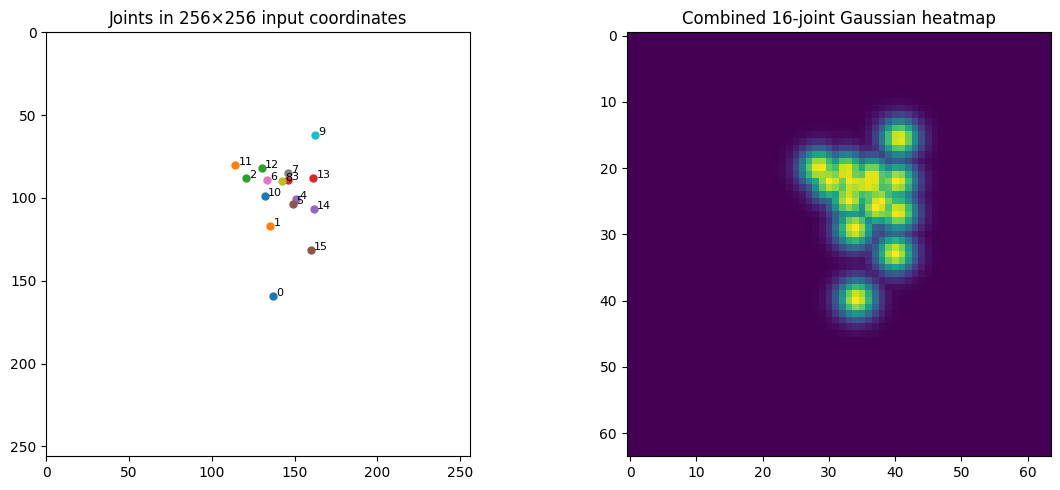

In [18]:
# ============================================================
# Step 4-6. MPII 이미지 없이 빈 256 256 좌표계 위에 관절 표시 후 16개 히트맵 최대값 합친 지도 눈으로 보기
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
)


# ------------------------------------------------------------
# Left: transformed joints in 256×256 input space
# ------------------------------------------------------------

axes[0].set_xlim(
    0,
    INPUT_WIDTH,
)

axes[0].set_ylim(
    INPUT_HEIGHT,
    0,
)

axes[0].set_aspect(
    "equal"
)

axes[0].set_title(
    "Joints in 256×256 input coordinates"
)


for i, (
    x,
    y,
) in enumerate(
    joints_input
):

    if target_weight[i] <= 0:
        continue

    axes[0].scatter(
        x,
        y,
        s=25,
    )

    axes[0].text(
        x + 2,
        y,
        str(i),
        fontsize=8,
    )


# ------------------------------------------------------------
# Right: combined heatmap
# ------------------------------------------------------------

combined_heatmap = (
    heatmaps.max(
        dim=0
    ).values
)

axes[1].imshow(
    combined_heatmap.numpy(),
    origin="upper",
)

axes[1].set_title(
    "Combined 16-joint Gaussian heatmap"
)


plt.tight_layout()
plt.show()

### 전처리 작업 과정 기록

LMS 원본 프로젝트의 crop 함수는 annotation의 `center`를 실제 crop 계산에
사용하지 않고 visible joint의 min/max와 `scale × 200` 마진을 이용하며,
직사각형 crop을 256×256으로 재편.

본 프로젝트에서는 두 모델의 동일하고 안정적인 입력 전처리를 위해
MPII의 `center`와 `scale`을 기반으로 affine transform을 적용했다.

SimpleBaseline/HRNet의 MPII 공식 구현에서 사용되는 방식에 맞추어:

- center y 위치 보정
- scale × 1.25 padding
- 256×256 affine transform
- 64×64 Gaussian heatmap
- sigma = 2

조건을 적용했다.

단계별 정리:


```
Annotation (x, y)
     │
     │ affine transform
     ▼
256×256 joint position
     │
     │ × 64/256
     ▼
64×64 joint position
     │
     │ Gaussian
     ▼
*[16, 64, 64] Ground Truth*
```

저 그라운드 트루스가 나중에


```
Hourglass output
[Batch, 16, 64, 64]

SimpleBaseline output
[Batch, 16, 64, 64]
```
MSE Loss 로 직접 비교될 정답 텐서다!

### MPII 실제 이미지 준비 및 전처리 검증

최종 구조:


```
/content/gd04_pose/data/mpii
│
├── annotations
│   ├── train.json
│   └── validation.json
│
├── images
│   ├── 015601864.jpg
│   ├── ...
│
└── mpii_human_pose_v1.tar.gz
```

## Step 5. MPII Image Dataset

지금까지 annotation만을 이용해 joint 좌표와 heatmap 생성을 검증했다.

이제 실제 MPII 이미지를 준비하여 다음 내용을 확인한다.

1. annotation의 image filename이 실제 이미지와 일치하는가?
2. 원본 joint 좌표가 사람 신체 위치에 올바르게 표시되는가?
3. `center`와 `scale` 기반 affine transform으로 사람이 정상적으로 crop되는가?
4. crop된 256×256 이미지와 변환된 joint 좌표가 정확히 일치하는가?

이 검증을 통과한 전처리만 이후 두 모델에 공통으로 사용한다.

In [19]:
# ============================================================
# Step 5-1. Download MPII image archive
# ============================================================

import subprocess
from pathlib import Path


MPII_IMAGE_URL = (
    "https://datasets.d2.mpi-inf.mpg.de/"
    "andriluka14cvpr/mpii_human_pose_v1.tar.gz"
)

MPII_ARCHIVE = (
    MPII_ROOT / "mpii_human_pose_v1.tar.gz"
)


print("Download URL:")
print(MPII_IMAGE_URL)

print("\nArchive path:")
print(MPII_ARCHIVE)


command = [
    "wget",
    "-c",                    # interrupted download resume
    MPII_IMAGE_URL,
    "-O",
    str(MPII_ARCHIVE),
]

subprocess.run(
    command,
    check=True,
)

Download URL:
https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz

Archive path:
/content/gd04_pose/data/mpii/mpii_human_pose_v1.tar.gz


CompletedProcess(args=['wget', '-c', 'https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz', '-O', '/content/gd04_pose/data/mpii/mpii_human_pose_v1.tar.gz'], returncode=0)

In [20]:
# ============================================================
# Step 5-2. 다운로드 크기가 얼마인가... 확인
# ============================================================

archive_size_gb = (
    MPII_ARCHIVE.stat().st_size
    / (1024 ** 3)
)

print(
    f"Archive size: "
    f"{archive_size_gb:.2f} GB"
)

print(
    "Archive exists:",
    MPII_ARCHIVE.exists(),
)

Archive size: 11.26 GB
Archive exists: True


In [21]:
# ============================================================
# Step 5-3. 압축 해제
# ============================================================

import subprocess


print(
    "Extracting archive..."
)

subprocess.run(
    [
        "tar",
        "-xf",
        str(MPII_ARCHIVE),
        "-C",
        str(MPII_ROOT),
    ],
    check=True,
)

print("Extraction complete.")

Extracting archive...
Extraction complete.


In [22]:
# ============================================================
# Step 5-4. Verify extracted images
# ============================================================

image_files = list(
    MPII_IMAGE_DIR.glob("*.jpg")
)

print(
    "Image directory:",
    MPII_IMAGE_DIR,
)

print(
    "Number of JPG images:",
    f"{len(image_files):,}",
)


sample_image_path = (
    MPII_IMAGE_DIR
    / train_annotations[0]["image"]
)

print(
    "\nFirst annotation image:",
    train_annotations[0]["image"],
)

print(
    "Exists:",
    sample_image_path.exists(),
)

print(
    "Path:",
    sample_image_path,
)

Image directory: /content/gd04_pose/data/mpii/images
Number of JPG images: 24,984

First annotation image: 015601864.jpg
Exists: True
Path: /content/gd04_pose/data/mpii/images/015601864.jpg


Original image size: (1280, 720)
Original image array: (720, 1280, 3)


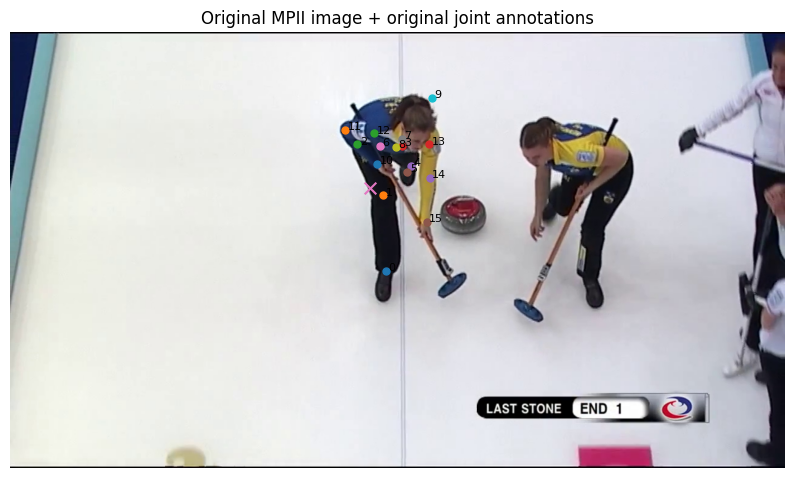

In [23]:
# ============================================================
# Step 5-5. 원본 이미지 JSON 좌표가 MPII 이미지 좧표와 일치하는지 검증하기
# ============================================================

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


sample = train_annotations[0]

image_path = (
    MPII_IMAGE_DIR
    / sample["image"]
)

image = Image.open(
    image_path
).convert("RGB")

image_np = np.asarray(
    image
)


original_joints = np.asarray(
    sample["joints"],
    dtype=np.float32,
)

original_vis = np.asarray(
    sample["joints_vis"],
    dtype=np.float32,
)

original_center = np.asarray(
    sample["center"],
    dtype=np.float32,
)


print(
    "Original image size:",
    image.size,
)

print(
    "Original image array:",
    image_np.shape,
)


plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    image_np
)

for idx, (x, y) in enumerate(
    original_joints
):

    if original_vis[idx] <= 0:
        continue

    plt.scatter(
        x,
        y,
        s=25,
    )

    plt.text(
        x + 4,
        y,
        str(idx),
        fontsize=8,
    )


plt.scatter(
    original_center[0],
    original_center[1],
    marker="x",
    s=70,
)

plt.title(
    "Original MPII image + original joint annotations"
)

plt.axis("off")
plt.show()

In [24]:
# ============================================================
# Step 5-6. 아핀 트랜스폼을 이미지에도 적용하기
# ============================================================

import cv2


center, scale = (
    prepare_mpii_center_scale(
        sample,
        scale_padding=SCALE_PADDING,
        center_y_shift=CENTER_Y_SHIFT,
    )
)


transform = get_affine_transform(
    center=center,
    scale=scale,
    output_size=(
        INPUT_WIDTH,
        INPUT_HEIGHT,
    ),
    rotation=0,
)


cropped_image = cv2.warpAffine(
    image_np,
    transform,
    (
        INPUT_WIDTH,
        INPUT_HEIGHT,
    ),
    flags=cv2.INTER_LINEAR,
)


joints_input, target_weight = (
    transform_joints_to_input(
        joints=sample["joints"],
        joints_vis=sample["joints_vis"],
        center=center,
        scale=scale,
        input_width=INPUT_WIDTH,
        input_height=INPUT_HEIGHT,
    )
)


print(
    "Cropped image shape:",
    cropped_image.shape,
)

print(
    "Joint tensor shape:",
    joints_input.shape,
)

Cropped image shape: (256, 256, 3)
Joint tensor shape: (16, 2)


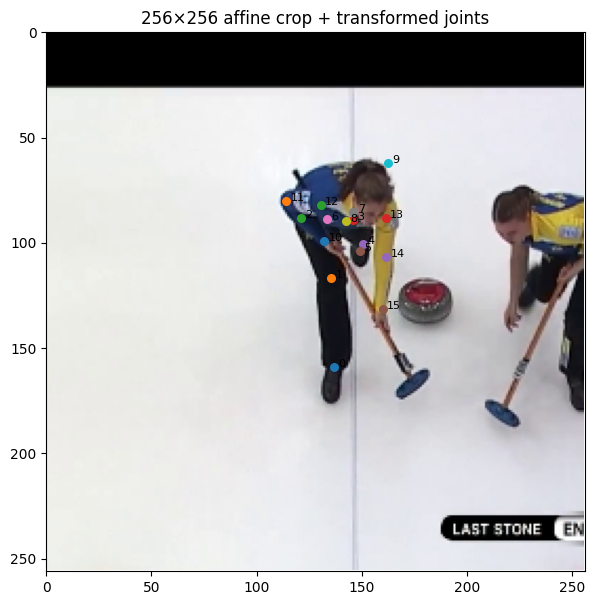

In [25]:
# ============================================================
# Step 5-7. Crop + transformed joints 검증!
# ============================================================

plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    cropped_image
)


for idx, (x, y) in enumerate(
    joints_input
):

    if target_weight[idx] <= 0:
        continue

    plt.scatter(
        x,
        y,
        s=30,
    )

    plt.text(
        x + 2,
        y,
        str(idx),
        fontsize=8,
    )


plt.xlim(
    0,
    INPUT_WIDTH,
)

plt.ylim(
    INPUT_HEIGHT,
    0,
)

plt.title(
    "256×256 affine crop + transformed joints"
)

plt.show()

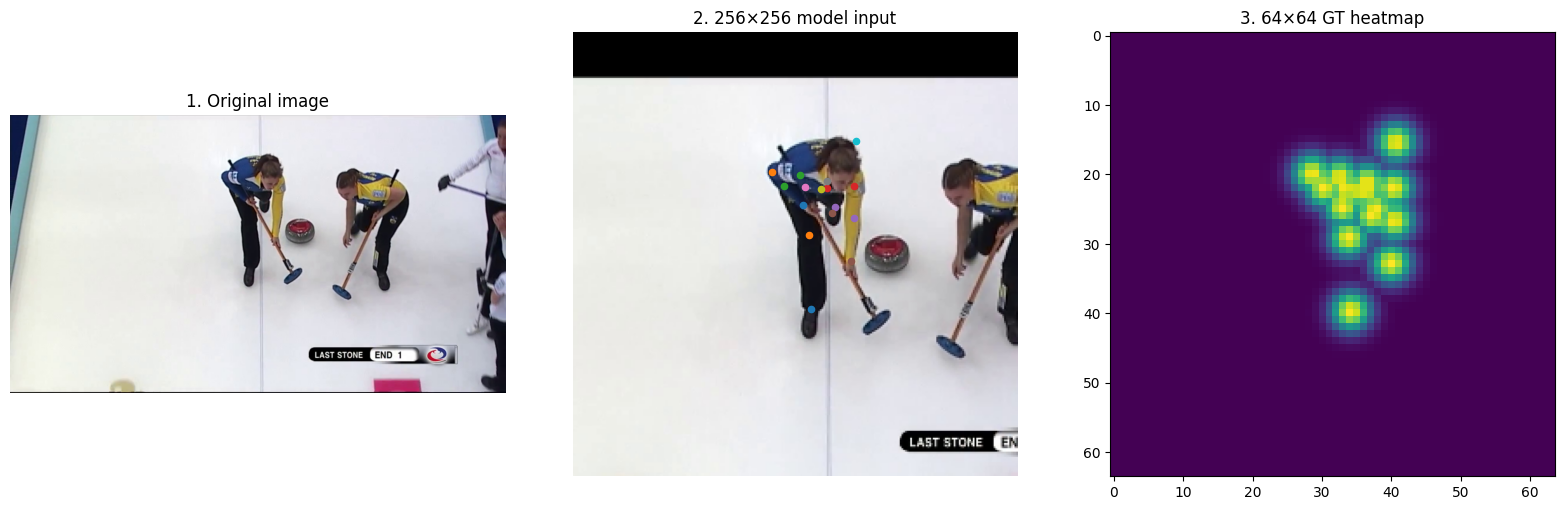

In [26]:
# ============================================================
# Step 5-8. Image → joints → ground-truth heatmap 데이터 파이프라인 확인해보기
# ============================================================

heatmaps, joints_heatmap, target_weight = (
    make_gaussian_heatmaps(
        joints_input=joints_input,
        target_weight=target_weight,

        input_size=(
            INPUT_HEIGHT,
            INPUT_WIDTH,
        ),

        heatmap_size=(
            HEATMAP_HEIGHT,
            HEATMAP_WIDTH,
        ),

        sigma=SIGMA,
    )
)


combined_heatmap = (
    heatmaps.max(
        dim=0
    ).values
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 5),
)


# Original
axes[0].imshow(
    image_np
)

axes[0].set_title(
    "1. Original image"
)

axes[0].axis(
    "off"
)


# Model input
axes[1].imshow(
    cropped_image
)

for idx, (x, y) in enumerate(
    joints_input
):

    if target_weight[idx] <= 0:
        continue

    axes[1].scatter(
        x,
        y,
        s=20,
    )

axes[1].set_title(
    "2. 256×256 model input"
)

axes[1].axis(
    "off"
)


# Ground truth
axes[2].imshow(
    combined_heatmap.numpy()
)

axes[2].set_title(
    "3. 64×64 GT heatmap"
)


plt.tight_layout()
plt.show()

이 흐름인즉


```
① 사진
   ↓
② 사람 중심 crop
   ↓
③ 256×256 입력
   ↓
④ joint 위치 변환
   ↓
⑤ 64×64 Gaussian
   ↓
⑥ Ground Truth
```

이후 모델은


```
256×256 image
        ↓
Hourglass 또는 SimpleBaseline
        ↓
Predicted [16,64,64]

                 ↕ MSE

Ground Truth [16,64,64]
```
학습함.

이 시점부터 Pose Estimation도 결국 지금까지 해온 지도학습과 같은 흐름으로 진행되는 것. 다만 차이점이 잇다면 Label 클래스 번호 하나가 아니라 16장으 ㅣ공간 지도가 되었다는점!


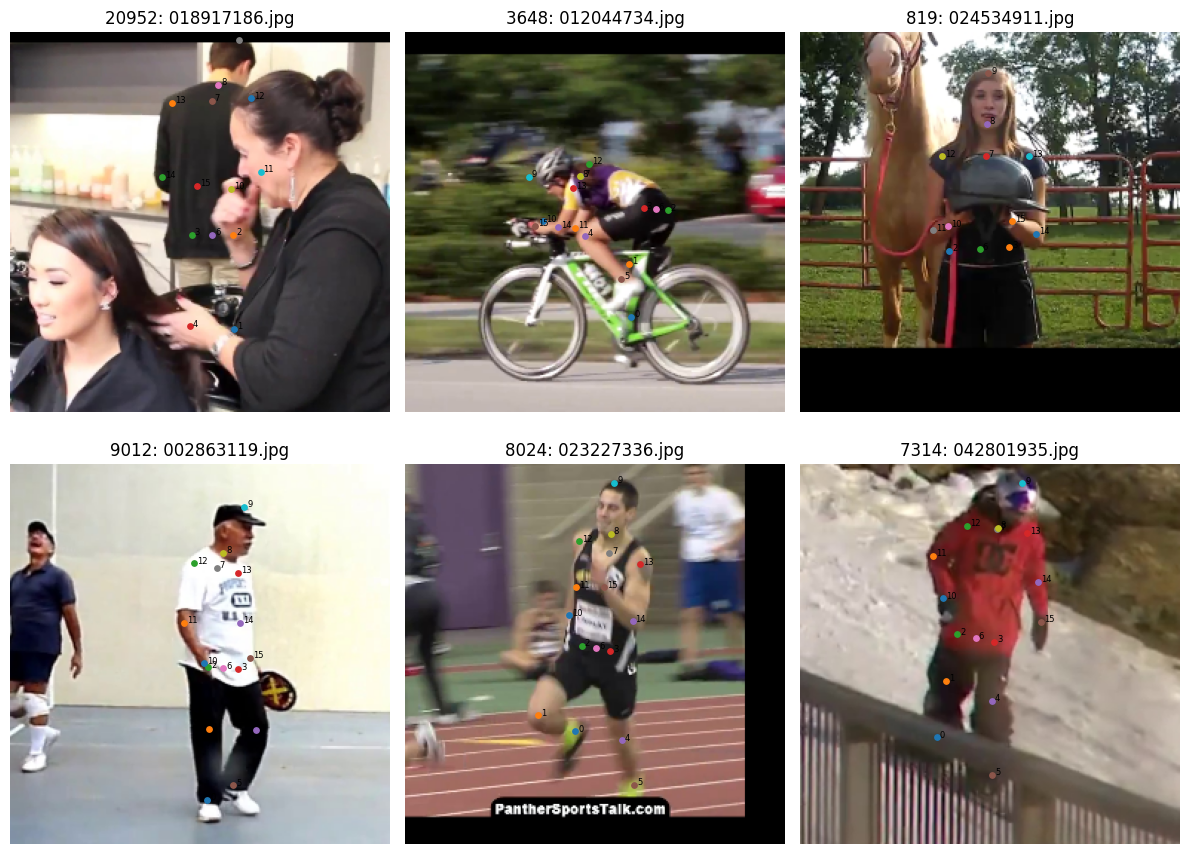

In [27]:
# ============================================================
# Step 5-9. Random preprocessing sanity check
# ============================================================

import random
import matplotlib.pyplot as plt
import numpy as np
import cv2
from PIL import Image


def preprocess_for_visual_check(annotation):

    image_path = (
        MPII_IMAGE_DIR
        / annotation["image"]
    )

    image = Image.open(
        image_path
    ).convert("RGB")

    image_np = np.asarray(image)

    center, scale = prepare_mpii_center_scale(
        annotation,
        scale_padding=SCALE_PADDING,
        center_y_shift=CENTER_Y_SHIFT,
    )

    transform = get_affine_transform(
        center=center,
        scale=scale,
        output_size=(
            INPUT_WIDTH,
            INPUT_HEIGHT,
        ),
        rotation=0,
    )

    cropped = cv2.warpAffine(
        image_np,
        transform,
        (
            INPUT_WIDTH,
            INPUT_HEIGHT,
        ),
        flags=cv2.INTER_LINEAR,
    )

    joints_input, weights = (
        transform_joints_to_input(
            joints=annotation["joints"],
            joints_vis=annotation["joints_vis"],
            center=center,
            scale=scale,
            input_width=INPUT_WIDTH,
            input_height=INPUT_HEIGHT,
        )
    )

    return cropped, joints_input, weights


rng = random.Random(SEED)

sample_indices = rng.sample(
    range(len(train_annotations)),
    6,
)


fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 9),
)

axes = axes.flatten()


for ax, sample_idx in zip(
    axes,
    sample_indices,
):

    annotation = train_annotations[
        sample_idx
    ]

    cropped, joints, weights = (
        preprocess_for_visual_check(
            annotation
        )
    )

    ax.imshow(cropped)

    for joint_id, (x, y) in enumerate(
        joints
    ):

        if weights[joint_id] <= 0:
            continue

        ax.scatter(
            x,
            y,
            s=15,
        )

        ax.text(
            x + 2,
            y,
            str(joint_id),
            fontsize=6,
        )

    ax.set_title(
        f"{sample_idx}: "
        f"{annotation['image']}"
    )

    ax.axis("off")


plt.tight_layout()
plt.show()

### 알아둬야하는 상식:
- TFRecord
= 데이터를 저장하는 파일 형식

- Dataset
= sample 하나를 어떻게 읽는지 정의

- DataLoader
= sample을 batch로 묶고
  여러 worker로 GPU에 공급

## Step 6. TFRecord Dataset Pipeline

MPII의 개별 JPEG 및 annotation을 학습에 적합한 TFRecord로 변환한다.

이번 프로젝트에서는 TFRecord에 다음 정보를 저장한다.

- 256×256 affine-cropped JPEG image
- transformed 16 joint coordinates
- joint visibility / target weight
- source filename

64×64 Gaussian heatmap은 저장하지 않고 Dataset에서 생성한다.

이를 통해 저장 공간을 과도하게 늘리지 않으면서
이미지 crop 및 annotation 좌표 변환의 반복 비용을 줄인다.

In [28]:
# ============================================================
# Step 6-0. Install TFRecord reader/writer
# ============================================================

%pip install -q "tfrecord[torch]==1.14.6"

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.0/80.0 kB 4.6 MB/s eta 0:00:00


In [29]:
# ============================================================
# Step 6-1. Verify TFRecord installation
# ============================================================

import tfrecord

from tfrecord import TFRecordWriter
from tfrecord.torch.dataset import (
    TFRecordDataset,
)

print(
    "tfrecord module:",
    tfrecord.__file__,
)

print(
    "TFRecordWriter:",
    TFRecordWriter,
)

print(
    "TFRecordDataset:",
    TFRecordDataset,
)

tfrecord module: /usr/local/lib/python3.13/dist-packages/tfrecord/__init__.py
TFRecordWriter: <class 'tfrecord.writer.TFRecordWriter'>
TFRecordDataset: <class 'tfrecord.torch.dataset.TFRecordDataset'>


#### 한 샘플당 TFRecord에는...


```
cropped 256×256 JPEG
+
16 joint 좌표
+
16 target weights
+
center / scale
+
원본 filename / sample index
```
그리고 학습할 때에는


```
TFRecord
 ↓
JPEG decode
 ↓
Tensor + Normalize
 ↓
joint 좌표 → Gaussian
 ↓
Image  [3,256,256]
Target [16,64,64]

```
이렇게 만들어서 병목을 예방함



In [31]:
# ============================================================
# Step 6-2. 8개짜리 파일럿 TFrecord 생성
# ============================================================

from tfrecord import TFRecordWriter
from tqdm.auto import tqdm
import cv2
import numpy as np


def annotation_to_tfrecord_example(
    annotation,
    sample_index,
    jpeg_quality=95,
):
    """
    MPII annotation 1개
        ↓
    256×256 affine crop
        ↓
    TFRecord에 저장할 tf.train.Example 형태
    """

    # --------------------------------------------------------
    # 1. Original image
    # --------------------------------------------------------
    image_path = (
        MPII_IMAGE_DIR
        / annotation["image"]
    )

    image_bgr = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR,
    )

    if image_bgr is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}"
        )

    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB,
    )


    # --------------------------------------------------------
    # 2. MPII center / scale
    # --------------------------------------------------------
    center, scale = prepare_mpii_center_scale(
        annotation,
        scale_padding=SCALE_PADDING,
        center_y_shift=CENTER_Y_SHIFT,
    )


    # --------------------------------------------------------
    # 3. Affine transform
    # --------------------------------------------------------
    transform = get_affine_transform(
        center=center,
        scale=scale,
        output_size=(
            INPUT_WIDTH,
            INPUT_HEIGHT,
        ),
        rotation=0,
    )


    cropped_rgb = cv2.warpAffine(
        image_rgb,
        transform,
        (
            INPUT_WIDTH,
            INPUT_HEIGHT,
        ),
        flags=cv2.INTER_LINEAR,
    )


    # --------------------------------------------------------
    # 4. Joint coordinates
    # --------------------------------------------------------
    joints_input, target_weight = (
        transform_joints_to_input(
            joints=annotation["joints"],
            joints_vis=annotation["joints_vis"],
            center=center,
            scale=scale,
            input_width=INPUT_WIDTH,
            input_height=INPUT_HEIGHT,
        )
    )


    # --------------------------------------------------------
    # 5. JPEG encode
    #
    # OpenCV encoder expects BGR ordering.
    # --------------------------------------------------------
    cropped_bgr = cv2.cvtColor(
        cropped_rgb,
        cv2.COLOR_RGB2BGR,
    )

    success, encoded = cv2.imencode(
        ".jpg",
        cropped_bgr,
        [
            cv2.IMWRITE_JPEG_QUALITY,
            jpeg_quality,
        ],
    )

    if not success:
        raise RuntimeError(
            f"JPEG encoding failed: {annotation['image']}"
        )


    # --------------------------------------------------------
    # 6. TFRecord features
    # --------------------------------------------------------
    example = {
        "image": (
            encoded.tobytes(),
            "byte",
        ),

        "joints": (
            joints_input
            .astype(np.float32)
            .reshape(-1),
            "float",
        ),

        "target_weight": (
            target_weight
            .astype(np.float32)
            .reshape(-1),
            "float",
        ),

        "center": (
            center.astype(np.float32),
            "float",
        ),

        "scale": (
            scale.astype(np.float32),
            "float",
        ),

        "sample_index": (
            int(sample_index),
            "int",
        ),

        "filename": (
            annotation["image"].encode("utf-8"),
            "byte",
        ),
    }

    return example

In [32]:
# ============================================================
# Step 6-3. Write tiny pilot TFRecord
# ============================================================

PILOT_TFRECORD = (
    LOCAL_TFRECORD_DIR
    / "pilot.tfrecord"
)

PILOT_INDEX = (
    LOCAL_TFRECORD_DIR
    / "pilot.index"
)


writer = TFRecordWriter(
    str(PILOT_TFRECORD)
)


for sample_index in range(8):

    example = annotation_to_tfrecord_example(
        train_annotations[sample_index],
        sample_index=sample_index,
    )

    writer.write(example)


writer.close()


print(
    "Pilot TFRecord:",
    PILOT_TFRECORD,
)

print(
    "Size:",
    f"{PILOT_TFRECORD.stat().st_size / 1024:.1f} KB",
)

Pilot TFRecord: /content/gd04_pose/tfrecords/pilot.tfrecord
Size: 161.2 KB


In [33]:
# ============================================================
# Step 6-4. Create TFRecord index
# ============================================================

import subprocess
import sys


subprocess.run(
    [
        sys.executable,
        "-m",
        "tfrecord.tools.tfrecord2idx",
        str(PILOT_TFRECORD),
        str(PILOT_INDEX),
    ],
    check=True,
)


print(
    "Index exists:",
    PILOT_INDEX.exists(),
)

print(
    "Index path:",
    PILOT_INDEX,
)

Index exists: True
Index path: /content/gd04_pose/tfrecords/pilot.index


In [34]:
# ============================================================
# Step 6-5. TFRecord 디코딩해서 다시 학습 Tensor로 바꾸기
# ============================================================

from tfrecord.torch.dataset import TFRecordDataset
import torch
import cv2
import numpy as np


TFRECORD_DESCRIPTION = {
    "image": "byte",
    "joints": "float",
    "target_weight": "float",
    "center": "float",
    "scale": "float",
    "sample_index": "int",
    "filename": "byte",
}

In [35]:
# ============================================================
# TFRecord Example
# → PyTorch training sample
# ============================================================

IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
).view(3, 1, 1)


def decode_byte_feature(value):

    if isinstance(value, bytes):
        return value

    return np.asarray(
        value,
        dtype=np.uint8,
    ).tobytes()


def decode_pose_record(features):

    # --------------------------------------------------------
    # 1. JPEG decode
    # --------------------------------------------------------
    image_bytes = decode_byte_feature(
        features["image"]
    )

    encoded_array = np.frombuffer(
        image_bytes,
        dtype=np.uint8,
    )

    image_bgr = cv2.imdecode(
        encoded_array,
        cv2.IMREAD_COLOR,
    )

    if image_bgr is None:
        raise RuntimeError(
            "TFRecord JPEG decoding failed."
        )


    image_rgb = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB,
    )


    # --------------------------------------------------------
    # 2. Image → PyTorch Tensor
    #
    # HWC → CHW
    # uint8 → float32
    # --------------------------------------------------------
    image_tensor = (
        torch
        .from_numpy(
            image_rgb.copy()
        )
        .permute(2, 0, 1)
        .float()
        / 255.0
    )


    # --------------------------------------------------------
    # 3. Normalize
    #
    # 두 모델에 완전히 동일하게 적용한다.
    # --------------------------------------------------------
    image_tensor = (
        image_tensor
        - IMAGENET_MEAN
    ) / IMAGENET_STD


    # --------------------------------------------------------
    # 4. Joint coordinates
    # --------------------------------------------------------
    joints_input = np.asarray(
        features["joints"],
        dtype=np.float32,
    ).reshape(
        NUM_JOINTS,
        2,
    )


    target_weight = np.asarray(
        features["target_weight"],
        dtype=np.float32,
    ).reshape(
        NUM_JOINTS,
    )


    # --------------------------------------------------------
    # 5. Gaussian target heatmaps
    # --------------------------------------------------------
    heatmaps, joints_heatmap, target_weight = (
        make_gaussian_heatmaps(
            joints_input=joints_input,
            target_weight=target_weight,

            input_size=(
                INPUT_HEIGHT,
                INPUT_WIDTH,
            ),

            heatmap_size=(
                HEATMAP_HEIGHT,
                HEATMAP_WIDTH,
            ),

            sigma=SIGMA,
        )
    )


    filename_bytes = decode_byte_feature(
        features["filename"]
    )

    filename = filename_bytes.decode(
        "utf-8"
    )


    return {
        "image": image_tensor,

        "target": heatmaps,

        "target_weight": torch.tensor(
            target_weight,
            dtype=torch.float32,
        ),

        "joints_input": torch.tensor(
            joints_input,
            dtype=torch.float32,
        ),

        "joints_heatmap": torch.tensor(
            joints_heatmap,
            dtype=torch.float32,
        ),

        "center": torch.tensor(
            features["center"],
            dtype=torch.float32,
        ),

        "scale": torch.tensor(
            features["scale"],
            dtype=torch.float32,
        ),

        "sample_index": int(
            np.asarray(
                features["sample_index"]
            ).reshape(-1)[0]
        ),

        "filename": filename,
    }

In [36]:
# ============================================================
# Step 6-6. 파일럿 데이터셋 검증
# ============================================================

pilot_dataset = TFRecordDataset(
    data_path=str(
        PILOT_TFRECORD
    ),

    index_path=str(
        PILOT_INDEX
    ),

    description=TFRECORD_DESCRIPTION,

    transform=decode_pose_record,
)


pilot_sample = next(
    iter(pilot_dataset)
)


print(
    "image          :",
    pilot_sample["image"].shape,
)

print(
    "target         :",
    pilot_sample["target"].shape,
)

print(
    "target_weight  :",
    pilot_sample["target_weight"].shape,
)

print(
    "joints_input   :",
    pilot_sample["joints_input"].shape,
)

print(
    "filename       :",
    pilot_sample["filename"],
)

print(
    "sample_index   :",
    pilot_sample["sample_index"],
)

image          : torch.Size([3, 256, 256])
target         : torch.Size([16, 64, 64])
target_weight  : torch.Size([16])
joints_input   : torch.Size([16, 2])
filename       : 086617615.jpg
sample_index   : 6


In [37]:
# ============================================================
# Step 6-7. Pilot DataLoader
# ============================================================

from torch.utils.data import DataLoader


pilot_loader = DataLoader(
    pilot_dataset,

    batch_size=4,

    num_workers=0,
)


pilot_batch = next(
    iter(pilot_loader)
)


print(
    "Batch images :",
    pilot_batch["image"].shape,
)

print(
    "Batch targets:",
    pilot_batch["target"].shape,
)

print(
    "Batch weights:",
    pilot_batch["target_weight"].shape,
)

Batch images : torch.Size([4, 3, 256, 256])
Batch targets: torch.Size([4, 16, 64, 64])
Batch weights: torch.Size([4, 16])


In [38]:
# ============================================================
# Step 6-8. 전체 TFRecord file 생성
# ============================================================

from pathlib import Path
from tqdm.auto import tqdm


TRAIN_TFRECORD = (
    LOCAL_TFRECORD_DIR
    / "train.tfrecord"
)

VAL_TFRECORD = (
    LOCAL_TFRECORD_DIR
    / "validation.tfrecord"
)

TRAIN_INDEX = (
    LOCAL_TFRECORD_DIR
    / "train.index"
)

VAL_INDEX = (
    LOCAL_TFRECORD_DIR
    / "validation.index"
)


def build_tfrecord(
    annotations,
    output_path,
):

    output_path = Path(
        output_path
    )

    temporary_path = Path(
        str(output_path) + ".tmp"
    )

    # 중간 실패 파일은 완성 파일로 취급하지 않는다.
    if temporary_path.exists():
        temporary_path.unlink()

    if output_path.exists():

        print(
            f"[exists] {output_path}"
        )

        return


    writer = TFRecordWriter(
        str(temporary_path)
    )


    try:

        for sample_index, annotation in tqdm(
            enumerate(annotations),
            total=len(annotations),
            desc=output_path.stem,
        ):

            example = (
                annotation_to_tfrecord_example(
                    annotation,
                    sample_index=sample_index,
                )
            )

            writer.write(
                example
            )

    finally:

        writer.close()


    temporary_path.replace(
        output_path
    )


    print(
        f"[done] {output_path}"
    )


build_tfrecord(
    train_annotations,
    TRAIN_TFRECORD,
)

build_tfrecord(
    val_annotations,
    VAL_TFRECORD,
)

train:   0%|          | 0/22246 [00:00<?, ?it/s]

[done] /content/gd04_pose/tfrecords/train.tfrecord


validation:   0%|          | 0/2958 [00:00<?, ?it/s]

[done] /content/gd04_pose/tfrecords/validation.tfrecord


In [39]:
# ============================================================
# Step 6-9. 전체 파일에 index 생성하기
# ============================================================

def create_tfrecord_index(
    tfrecord_path,
    index_path,
):

    subprocess.run(
        [
            sys.executable,
            "-m",
            "tfrecord.tools.tfrecord2idx",
            str(tfrecord_path),
            str(index_path),
        ],
        check=True,
    )


create_tfrecord_index(
    TRAIN_TFRECORD,
    TRAIN_INDEX,
)

create_tfrecord_index(
    VAL_TFRECORD,
    VAL_INDEX,
)


print(
    "Train index:",
    TRAIN_INDEX.exists(),
)

print(
    "Validation index:",
    VAL_INDEX.exists(),
)

Train index: True
Validation index: True


In [40]:
# ============================================================
# Step 6-10. 레코드 수 검증
# ============================================================

def count_index_rows(path):

    with open(
        path,
        "r",
        encoding="utf-8",
    ) as f:

        return sum(
            1
            for _ in f
        )


train_record_count = (
    count_index_rows(
        TRAIN_INDEX
    )
)

val_record_count = (
    count_index_rows(
        VAL_INDEX
    )
)


print(
    "Train records:",
    f"{train_record_count:,}",
    "/",
    f"{len(train_annotations):,}",
)

print(
    "Validation records:",
    f"{val_record_count:,}",
    "/",
    f"{len(val_annotations):,}",
)


for path in [
    TRAIN_TFRECORD,
    VAL_TFRECORD,
]:

    size_gb = (
        path.stat().st_size
        / (1024 ** 3)
    )

    print(
        f"{path.name:<25}"
        f"{size_gb:.2f} GB"
    )

Train records: 22,246 / 22,246
Validation records: 2,958 / 2,958
train.tfrecord           0.49 GB
validation.tfrecord      0.07 GB


#### 현재까지의 단계를 정리해드립니다~



```
MPII raw image + annotation
          ↓
전처리 / 좌표 변환
          ↓
TFRecord
          ↓
Dataset
          ↓
DataLoader
          ↓
[B,3,256,256]
          ↓
━━━━━━━━━━━━━━━━━━
여기서부터 Model
━━━━━━━━━━━━━━━━━━
          ↓
[B,16,64,64]
          ↓
MSE Loss
          ↓
Backward
          ↓
Optimizer
```



### TFRecord cache

생성된 TFRecord는 Colab local disk에서 학습에 사용하고,
런타임 종료 후에도 재사용할 수 있도록 Google Drive에도 보관한다.

이후 새 런타임에서는 12GB 이상의 MPII 원본 이미지를 다시 다운로드하지 않고,
약 0.56GB의 TFRecord만 local disk로 복사하여 학습을 재개할 수 있다.

In [41]:
# ============================================================
# Step 6-11. Cache TFRecords to Google Drive
# ============================================================

import shutil
import json
from pathlib import Path


DRIVE_TFRECORD_DIR = (
    DRIVE_MPII_DIR / "tfrecords"
)

DRIVE_TFRECORD_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


files_to_cache = [
    TRAIN_TFRECORD,
    TRAIN_INDEX,
    VAL_TFRECORD,
    VAL_INDEX,
]


def copy_if_needed(
    source,
    destination,
):
    source = Path(source)
    destination = Path(destination)

    if (
        destination.exists()
        and destination.stat().st_size
        == source.stat().st_size
    ):
        print(
            f"[same] {destination.name}"
        )
        return

    shutil.copy2(
        source,
        destination,
    )

    print(
        f"[copied] {destination.name}"
    )


for source in files_to_cache:

    destination = (
        DRIVE_TFRECORD_DIR
        / source.name
    )

    copy_if_needed(
        source,
        destination,
    )


tfrecord_manifest = {
    "train_records": train_record_count,
    "validation_records": val_record_count,

    "train_tfrecord_bytes":
        TRAIN_TFRECORD.stat().st_size,

    "validation_tfrecord_bytes":
        VAL_TFRECORD.stat().st_size,

    "train_build_time_seconds": 256,
    "validation_build_time_seconds": 34,

    "input_size": [
        INPUT_HEIGHT,
        INPUT_WIDTH,
    ],

    "heatmap_size": [
        HEATMAP_HEIGHT,
        HEATMAP_WIDTH,
    ],

    "num_joints": NUM_JOINTS,
    "heatmap_sigma": SIGMA,
}


with open(
    CONFIG_DIR / "tfrecord_manifest.json",
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        tfrecord_manifest,
        f,
        indent=2,
        ensure_ascii=False,
    )


print(
    "\nDrive cache:",
    DRIVE_TFRECORD_DIR,
)

[copied] train.tfrecord
[copied] train.index
[copied] validation.tfrecord
[copied] validation.index

Drive cache: /content/drive/MyDrive/Colab Notebooks/2026.789_AI researcher/GD04_Pose_Estimation/data/mpii/tfrecords


### Full PyTorch DataLoader

TFRecord는 저장 형식이고,
`TFRecordDataset`은 record 하나를 PyTorch sample로 변환하며,
`DataLoader`는 여러 sample을 batch로 묶어 GPU에 공급한다.

Train set에는 buffer shuffle을 적용하고,
Validation set은 순서를 변경하지 않는다.

In [42]:
# ============================================================
# Step 6-12. Full TFRecord Dataset & DataLoader
# ============================================================

from tfrecord.torch.dataset import (
    TFRecordDataset,
)

from torch.utils.data import (
    DataLoader,
)


TRAIN_SHUFFLE_BUFFER = 2048


train_dataset = TFRecordDataset(
    data_path=str(
        TRAIN_TFRECORD
    ),

    index_path=str(
        TRAIN_INDEX
    ),

    description=TFRECORD_DESCRIPTION,

    shuffle_queue_size=(
        TRAIN_SHUFFLE_BUFFER
    ),

    transform=decode_pose_record,
)


val_dataset = TFRecordDataset(
    data_path=str(
        VAL_TFRECORD
    ),

    index_path=str(
        VAL_INDEX
    ),

    description=TFRECORD_DESCRIPTION,

    shuffle_queue_size=None,

    transform=decode_pose_record,
)


loader_generator = (
    torch.Generator()
    .manual_seed(SEED)
)


common_loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
    "generator": loader_generator,
}


if NUM_WORKERS > 0:

    common_loader_kwargs.update({
        "persistent_workers": True,
        "prefetch_factor": 2,
    })


train_loader = DataLoader(
    train_dataset,

    drop_last=True,

    **common_loader_kwargs,
)


val_loader = DataLoader(
    val_dataset,

    drop_last=False,

    **common_loader_kwargs,
)


print(
    "Batch size :",
    BATCH_SIZE,
)

print(
    "Workers    :",
    NUM_WORKERS,
)

print(
    "Pin memory :",
    True,
)

Batch size : 8
Workers    : 2
Pin memory : True


In [43]:
# ============================================================
# Step 6-13. 전체 데이터셋의 첫 배치 확인
# ============================================================

import time


start_time = time.perf_counter()

train_batch = next(
    iter(train_loader)
)

load_time = (
    time.perf_counter()
    - start_time
)


print(
    "Batch images :",
    train_batch["image"].shape,
)

print(
    "Batch targets:",
    train_batch["target"].shape,
)

print(
    "Batch weights:",
    train_batch[
        "target_weight"
    ].shape,
)

print(
    "Batch load time:",
    f"{load_time:.3f} sec",
)

Batch images : torch.Size([8, 3, 256, 256])
Batch targets: torch.Size([8, 16, 64, 64])
Batch weights: torch.Size([8, 16])
Batch load time: 0.475 sec


### Stacked Hourglass라면 무릇


```
x = x + inter1 + inter2

```

이전 피처를 보존해서 이어주는 형태가 돼야함.



## Step 7. Stacked Hourglass Network

Stacked Hourglass는 서로 다른 공간 해상도에서 feature를 처리한 뒤
skip connection으로 다시 결합하는 구조이다.

각 Hourglass 내부의 기본 구성 요소는 Residual Bottleneck Block이다.

Residual connection:

`output = F(x) + x`

를 통해 기존 feature를 보존하면서 새로운 feature를 학습한다.

In [44]:
# ============================================================
# Step 7-1. Residual Bottleneck Block
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


BN_MOMENTUM = 0.1


class BottleneckBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        filters,
        stride=1,
        downsample=False,
    ):

        super().__init__()

        self.downsample = downsample


        if self.downsample:

            self.downsample_conv = (
                nn.Conv2d(
                    in_channels,
                    filters,

                    kernel_size=1,
                    stride=stride,

                    bias=False,
                )
            )


        # Pre-activation residual block
        self.bn1 = nn.BatchNorm2d(
            in_channels,
            momentum=BN_MOMENTUM,
        )

        self.relu = nn.ReLU(
            inplace=True
        )


        self.conv1 = nn.Conv2d(
            in_channels,
            filters // 2,

            kernel_size=1,
            bias=False,
        )


        self.bn2 = nn.BatchNorm2d(
            filters // 2,
            momentum=BN_MOMENTUM,
        )


        self.conv2 = nn.Conv2d(
            filters // 2,
            filters // 2,

            kernel_size=3,
            stride=stride,
            padding=1,

            bias=False,
        )


        self.bn3 = nn.BatchNorm2d(
            filters // 2,
            momentum=BN_MOMENTUM,
        )


        self.conv3 = nn.Conv2d(
            filters // 2,
            filters,

            kernel_size=1,
            bias=False,
        )


    def forward(
        self,
        x,
    ):

        identity = x


        if self.downsample:

            identity = (
                self.downsample_conv(
                    x
                )
            )


        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)


        out = (
            out
            + identity
        )


        return out

In [45]:
# ============================================================
# Step 7-2. 아워글래스 하나 구현
# ============================================================

class HourglassModule(nn.Module):

    def __init__(
        self,
        order,
        filters,
        num_residual,
    ):

        super().__init__()

        self.order = order


        # ----------------------------------------------------
        # High-resolution branch
        # ----------------------------------------------------

        self.up1_0 = BottleneckBlock(
            in_channels=filters,
            filters=filters,
            downsample=False,
        )


        self.up1_blocks = nn.Sequential(
            *[
                BottleneckBlock(
                    in_channels=filters,
                    filters=filters,
                    downsample=False,
                )

                for _ in range(
                    num_residual
                )
            ]
        )


        # ----------------------------------------------------
        # Low-resolution branch
        # ----------------------------------------------------

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )


        self.low1_blocks = nn.Sequential(
            *[
                BottleneckBlock(
                    in_channels=filters,
                    filters=filters,
                    downsample=False,
                )

                for _ in range(
                    num_residual
                )
            ]
        )


        # ----------------------------------------------------
        # Recursive Hourglass
        # ----------------------------------------------------

        if order > 1:

            self.low2 = (
                HourglassModule(
                    order=order - 1,
                    filters=filters,
                    num_residual=(
                        num_residual
                    ),
                )
            )

        else:

            self.low2 = nn.Sequential(
                *[
                    BottleneckBlock(
                        in_channels=filters,
                        filters=filters,
                        downsample=False,
                    )

                    for _ in range(
                        num_residual
                    )
                ]
            )


        self.low3_blocks = nn.Sequential(
            *[
                BottleneckBlock(
                    in_channels=filters,
                    filters=filters,
                    downsample=False,
                )

                for _ in range(
                    num_residual
                )
            ]
        )


    def forward(
        self,
        x,
    ):

        # High-resolution path
        up1 = self.up1_0(x)
        up1 = self.up1_blocks(
            up1
        )


        # Low-resolution path
        low1 = self.pool(x)

        low1 = self.low1_blocks(
            low1
        )

        low2 = self.low2(
            low1
        )

        low3 = self.low3_blocks(
            low2
        )


        up2 = F.interpolate(
            low3,

            scale_factor=2,

            mode="nearest",
        )


        # --------------------------------------------
        # Element-wise addition
        # --------------------------------------------

        return (
            up1
            + up2
        )



```
고해상도 위치 정보
       +
저해상도에서 다시 올라온 문맥 정보
       ↓
결합된 feature
```



In [46]:
# ============================================================
# Step 7-3. Linear Layer
# ============================================================

class LinearLayer(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
    ):

        super().__init__()


        self.conv = nn.Conv2d(
            in_channels,
            out_channels,

            kernel_size=1,

            bias=False,
        )


        self.bn = nn.BatchNorm2d(
            out_channels,
            momentum=BN_MOMENTUM,
        )


        self.relu = nn.ReLU(
            inplace=True
        )


    def forward(
        self,
        x,
    ):

        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)

        return x

여기서 1x1 conv는


```
공간 64×64 유지
+
채널 feature 변환
```

역할이다.

In [47]:
# ============================================================
# Step 7-4. Stacked Hourglass Network
# ============================================================

class StackedHourglassNetwork(
    nn.Module
):

    def __init__(
        self,
        num_stack=4,
        num_residual=1,
        num_heatmap=16,
    ):

        super().__init__()


        self.num_stack = (
            num_stack
        )


        # ----------------------------------------------------
        # Input stem
        #
        # 256×256
        # → 128×128
        # → 64×64
        # ----------------------------------------------------

        self.conv1 = nn.Conv2d(
            3,
            64,

            kernel_size=7,
            stride=2,
            padding=3,

            bias=False,
        )


        self.bn1 = nn.BatchNorm2d(
            64,
            momentum=BN_MOMENTUM,
        )


        self.relu = nn.ReLU(
            inplace=True
        )


        self.bottleneck1 = (
            BottleneckBlock(
                in_channels=64,
                filters=128,
                downsample=True,
            )
        )


        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
        )


        self.bottleneck2 = (
            BottleneckBlock(
                in_channels=128,
                filters=128,
                downsample=False,
            )
        )


        self.bottleneck3 = (
            BottleneckBlock(
                in_channels=128,
                filters=256,
                downsample=True,
            )
        )


        # ----------------------------------------------------
        # Four Hourglass stacks
        # ----------------------------------------------------

        self.hourglass_modules = (
            nn.ModuleList()
        )

        self.residual_modules = (
            nn.ModuleList()
        )

        self.linear_layers = (
            nn.ModuleList()
        )

        self.heatmap_convs = (
            nn.ModuleList()
        )


        self.intermediate_convs = (
            nn.ModuleList()
        )

        self.intermediate_outs = (
            nn.ModuleList()
        )


        for stack_id in range(
            num_stack
        ):

            self.hourglass_modules.append(
                HourglassModule(
                    order=4,
                    filters=256,
                    num_residual=(
                        num_residual
                    ),
                )
            )


            self.residual_modules.append(
                nn.Sequential(
                    *[
                        BottleneckBlock(
                            in_channels=256,
                            filters=256,
                            downsample=False,
                        )

                        for _ in range(
                            num_residual
                        )
                    ]
                )
            )


            self.linear_layers.append(
                LinearLayer(
                    in_channels=256,
                    out_channels=256,
                )
            )


            # 256 feature channels
            # → 16 joint heatmaps
            self.heatmap_convs.append(
                nn.Conv2d(
                    256,
                    num_heatmap,

                    kernel_size=1,
                )
            )


            if (
                stack_id
                < num_stack - 1
            ):

                self.intermediate_convs.append(
                    nn.Conv2d(
                        256,
                        256,
                        kernel_size=1,
                    )
                )


                self.intermediate_outs.append(
                    nn.Conv2d(
                        num_heatmap,
                        256,
                        kernel_size=1,
                    )
                )


    def forward(
        self,
        x,
    ):

        # ----------------------------------------------------
        # Stem
        # ----------------------------------------------------

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.bottleneck1(x)

        x = self.pool(x)

        x = self.bottleneck2(x)
        x = self.bottleneck3(x)


        outputs = []


        # ----------------------------------------------------
        # Stacked Hourglass
        # ----------------------------------------------------

        for stack_id in range(
            self.num_stack
        ):

            hg = (
                self.hourglass_modules[
                    stack_id
                ](x)
            )


            res = (
                self.residual_modules[
                    stack_id
                ](hg)
            )


            features = (
                self.linear_layers[
                    stack_id
                ](res)
            )


            heatmap = (
                self.heatmap_convs[
                    stack_id
                ](features)
            )


            outputs.append(
                heatmap
            )


            if (
                stack_id
                < self.num_stack - 1
            ):

                merged_features = (
                    self.intermediate_convs[
                        stack_id
                    ](features)
                )


                merged_heatmap = (
                    self.intermediate_outs[
                        stack_id
                    ](heatmap)
                )


                # --------------------------------------------
                # 이전 feature도 보존하는 residual 연결
                # --------------------------------------------

                x = (
                    x
                    + merged_features
                    + merged_heatmap
                )


        return outputs

In [48]:
# ============================================================
# Step 7-5. shape 확인하기
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


hourglass_model = (
    StackedHourglassNetwork(
        num_stack=4,
        num_residual=1,
        num_heatmap=NUM_JOINTS,
    )
    .to(device)
)


dummy_input = torch.zeros(
    1,
    3,
    INPUT_HEIGHT,
    INPUT_WIDTH,

    device=device,
)


hourglass_model.eval()


with torch.inference_mode():

    outputs = (
        hourglass_model(
            dummy_input
        )
    )


print(
    "Number of stacks:",
    len(outputs),
)


for stack_id, output in enumerate(
    outputs,
    start=1,
):

    print(
        f"Stack {stack_id}:",
        output.shape,
    )


num_parameters = sum(
    p.numel()
    for p in hourglass_model.parameters()
)


print(
    "\nParameters:",
    f"{num_parameters:,}",
)

Number of stacks: 4
Stack 1: torch.Size([1, 16, 64, 64])
Stack 2: torch.Size([1, 16, 64, 64])
Stack 3: torch.Size([1, 16, 64, 64])
Stack 4: torch.Size([1, 16, 64, 64])

Parameters: 16,251,392


#### 위 구조 부연설명


```
Input
[1,3,256,256]

        ↓

Stem
[1,256,64,64]

        ↓

Hourglass 1
→ [1,16,64,64] ─ Loss 1

        ↓

Hourglass 2
→ [1,16,64,64] ─ Loss 2

        ↓

Hourglass 3
→ [1,16,64,64] ─ Loss 3

        ↓

Hourglass 4
→ [1,16,64,64] ─ Final Loss
```



## Step 8. Weighted Heatmap MSE Loss

Pose Estimation의 정답은 클래스 번호가 아니라
관절별 Gaussian heatmap이다.

각 모델의 예측 heatmap과 ground-truth heatmap 사이의
Mean Squared Error(MSE)를 계산한다.

MPII의 `joints_vis`를 기반으로 생성한 `target_weight`를 사용하여
학습에 사용할 수 없는 관절은 loss에서 제외한다.

Stacked Hourglass는 4개의 stack에서 각각 heatmap을 출력하므로
각 stack에 동일한 supervision을 적용하고,
네 stack의 loss 평균을 최종 loss로 사용한다.

이를 통해 중간 stack에도 직접 gradient가 전달된다.

In [49]:
# ============================================================
# Step 8-1. Weighted Heatmap MSE Loss
# ============================================================

class WeightedHeatmapMSELoss(nn.Module):

    def __init__(self):
        super().__init__()


    def single_output_loss(
        self,
        prediction,
        target,
        target_weight,
    ):
        """
        prediction:
            [B, J, H, W]

        target:
            [B, J, H, W]

        target_weight:
            [B, J]
        """

        # ------------------------------------------
        # 1. Pixel-wise squared error
        # ------------------------------------------

        squared_error = (
            prediction - target
        ) ** 2

        # [B, J, H, W]
        # ↓ spatial mean
        # [B, J]

        joint_loss = squared_error.mean(
            dim=(2, 3)
        )


        # ------------------------------------------
        # 2. Visibility mask
        # ------------------------------------------

        weighted_joint_loss = (
            joint_loss
            * target_weight
        )


        # 실제 supervision이 존재하는
        # joint 개수로 정규화
        valid_joint_count = (
            target_weight.sum()
            .clamp_min(1.0)
        )


        loss = (
            weighted_joint_loss.sum()
            / valid_joint_count
        )

        return loss


    def forward(
        self,
        outputs,
        target,
        target_weight,
    ):

        # ------------------------------------------
        # SimpleBaseline처럼 Tensor 하나가 들어와도
        # 동일한 loss 함수를 사용할 수 있게 처리
        # ------------------------------------------

        if torch.is_tensor(outputs):

            outputs = [outputs]


        stack_losses = []


        for output in outputs:

            stack_loss = (
                self.single_output_loss(
                    prediction=output,
                    target=target,
                    target_weight=target_weight,
                )
            )

            stack_losses.append(
                stack_loss
            )


        # ------------------------------------------
        # Intermediate supervision:
        # 모든 stack loss 평균
        # ------------------------------------------

        total_loss = torch.stack(
            stack_losses
        ).mean()


        return (
            total_loss,
            stack_losses,
        )


criterion = (
    WeightedHeatmapMSELoss()
)

print(criterion)

WeightedHeatmapMSELoss()


#### 왜 Loss를 합치냐면요,

Hourglass가


```
Stack 1 → prediction 1
Stack 2 → prediction 2
Stack 3 → prediction 3
Stack 4 → prediction 4
```
구성이기 때문입니다.



```
GT ─────────────┐
                ↓
Stack 1 ───→ Loss 1

GT ─────────────┐
                ↓
Stack 2 ───→ Loss 2

GT ─────────────┐
                ↓
Stack 3 ───→ Loss 3

GT ─────────────┐
                ↓
Stack 4 ───→ Loss 4
```



```
Final Loss
=
(L1 + L2 + L3 + L4) / 4
```




In [50]:
# ============================================================
# Step 8-2. Optimizer
# ============================================================

optimizer = torch.optim.Adam(
    hourglass_model.parameters(),
    lr=LEARNING_RATE,
)


print(
    "Optimizer    :",
    type(optimizer).__name__,
)

print(
    "Learning rate:",
    optimizer.param_groups[0]["lr"],
)

Optimizer    : Adam
Learning rate: 0.0007


In [51]:
# ============================================================
# Step 8-3. Prepare one real training batch
# ============================================================

train_batch = next(
    iter(train_loader)
)


images = train_batch[
    "image"
].to(
    device,
    non_blocking=True,
)


targets = train_batch[
    "target"
].to(
    device,
    non_blocking=True,
)


target_weights = train_batch[
    "target_weight"
].to(
    device,
    non_blocking=True,
)


print(
    "Images :",
    images.shape,
    images.device,
)

print(
    "Targets:",
    targets.shape,
    targets.device,
)

print(
    "Weights:",
    target_weights.shape,
    target_weights.device,
)

Images : torch.Size([8, 3, 256, 256]) cuda:0
Targets: torch.Size([8, 16, 64, 64]) cuda:0
Weights: torch.Size([8, 16]) cuda:0


In [52]:
# ============================================================
# Step 8-4. Forward + loss 먼저 체크
# ============================================================

hourglass_model.train()


outputs = hourglass_model(
    images
)


loss, stack_losses = criterion(
    outputs=outputs,
    target=targets,
    target_weight=target_weights,
)


print(
    "Total loss:",
    float(loss.detach()),
)


for stack_id, stack_loss in enumerate(
    stack_losses,
    start=1,
):

    print(
        f"Stack {stack_id} loss:",
        float(
            stack_loss.detach()
        ),
    )


print(
    "\nLoss finite:",
    bool(
        torch.isfinite(loss)
    ),
)

Total loss: 0.17181414365768433
Stack 1 loss: 0.12880508601665497
Stack 2 loss: 0.2109352946281433
Stack 3 loss: 0.1716642677783966
Stack 4 loss: 0.17585192620754242

Loss finite: True


In [53]:
# ============================================================
# Step 8-5. 처음 역전파 시작~!
#
# Forward
# → Loss
# → Backward
# → Optimizer update
# ============================================================

hourglass_model.train()


optimizer.zero_grad(
    set_to_none=True
)


outputs = hourglass_model(
    images
)


loss, stack_losses = criterion(
    outputs=outputs,
    target=targets,
    target_weight=target_weights,
)


loss.backward()


# ------------------------------------------------------------
# Gradient가 실제로 생성됐는지 확인
# ------------------------------------------------------------

grad_norm_sq = 0.0


for parameter in (
    hourglass_model.parameters()
):

    if parameter.grad is None:
        continue

    grad_norm_sq += (
        parameter.grad
        .detach()
        .float()
        .norm(2)
        .item()
        ** 2
    )


grad_norm = (
    grad_norm_sq ** 0.5
)


optimizer.step()


print(
    "Loss:",
    float(
        loss.detach()
    ),
)

print(
    "Gradient norm:",
    grad_norm,
)

print(
    "Gradient finite:",
    np.isfinite(
        grad_norm
    ),
)

Loss: 0.17181414365768433
Gradient norm: 1.335692154206323
Gradient finite: True


## Step 9. Training Performance Benchmark

본 학습 전에 현재 Colab L4 환경에서
Stacked Hourglass의 실제 training throughput과 GPU memory를 측정한다.

루브릭의 1 epoch 30분 이내 조건을 확인한 후
두 모델에 공통으로 사용할 batch size를 확정한다.

먼저 batch size 8에서 측정하고,
메모리 여유가 충분할 경우 batch size 16을 추가 검토한다.

In [54]:
# ============================================================
# Step 9-1. 모델 초기화
# ============================================================

import gc
import random
import numpy as np
import torch


def reset_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


reset_seed(SEED)


# 기존 GPU 객체 정리
del hourglass_model
del optimizer

gc.collect()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()


hourglass_model = StackedHourglassNetwork(
    num_stack=4,
    num_residual=1,
    num_heatmap=NUM_JOINTS,
).to(device)


optimizer = torch.optim.Adam(
    hourglass_model.parameters(),
    lr=LEARNING_RATE,
)


criterion = WeightedHeatmapMSELoss()


print(
    "Model reset complete."
)

Model reset complete.


In [55]:
# ============================================================
# Step 9-2. 실제 학습 성과 측정 20batch
# ============================================================

import time
import itertools


WARMUP_STEPS = 5
BENCHMARK_STEPS = 20


hourglass_model.train()

train_iterator = iter(
    train_loader
)


# ------------------------------------------------------------
# Warm-up
# ------------------------------------------------------------

print("Warming up...")


for _ in range(WARMUP_STEPS):

    batch = next(
        train_iterator
    )

    images = batch["image"].to(
        device,
        non_blocking=True,
    )

    targets = batch["target"].to(
        device,
        non_blocking=True,
    )

    target_weights = batch[
        "target_weight"
    ].to(
        device,
        non_blocking=True,
    )


    optimizer.zero_grad(
        set_to_none=True
    )


    outputs = hourglass_model(
        images
    )


    loss, _ = criterion(
        outputs,
        targets,
        target_weights,
    )


    loss.backward()

    optimizer.step()


# GPU 작업 완료 대기
torch.cuda.synchronize()


# ------------------------------------------------------------
# Benchmark
# ------------------------------------------------------------

torch.cuda.reset_peak_memory_stats()

start_time = time.perf_counter()

benchmark_losses = []


for step in range(
    BENCHMARK_STEPS
):

    batch = next(
        train_iterator
    )


    images = batch["image"].to(
        device,
        non_blocking=True,
    )

    targets = batch["target"].to(
        device,
        non_blocking=True,
    )

    target_weights = batch[
        "target_weight"
    ].to(
        device,
        non_blocking=True,
    )


    optimizer.zero_grad(
        set_to_none=True
    )


    outputs = hourglass_model(
        images
    )


    loss, _ = criterion(
        outputs,
        targets,
        target_weights,
    )


    loss.backward()

    optimizer.step()


    benchmark_losses.append(
        loss.detach().item()
    )


torch.cuda.synchronize()

elapsed = (
    time.perf_counter()
    - start_time
)


seconds_per_step = (
    elapsed
    / BENCHMARK_STEPS
)

samples_per_second = (
    BATCH_SIZE
    / seconds_per_step
)


peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)


# ------------------------------------------------------------
# 1 epoch 예상 시간
# ------------------------------------------------------------

steps_per_epoch = (
    train_record_count
    // BATCH_SIZE
)


estimated_epoch_seconds = (
    steps_per_epoch
    * seconds_per_step
)


estimated_epoch_minutes = (
    estimated_epoch_seconds
    / 60
)


print("=" * 60)

print(
    "Batch size            :",
    BATCH_SIZE,
)

print(
    "Benchmark steps       :",
    BENCHMARK_STEPS,
)

print(
    "Seconds / step        :",
    f"{seconds_per_step:.4f}",
)

print(
    "Samples / second      :",
    f"{samples_per_second:.2f}",
)

print(
    "Peak GPU memory       :",
    f"{peak_memory_gb:.2f} GB",
)

print(
    "Steps / epoch         :",
    f"{steps_per_epoch:,}",
)

print(
    "Estimated epoch time  :",
    f"{estimated_epoch_minutes:.2f} min",
)

print(
    "Mean benchmark loss   :",
    f"{np.mean(benchmark_losses):.6f}",
)

print("=" * 60)

Warming up...
Batch size            : 8
Benchmark steps       : 20
Seconds / step        : 0.1513
Samples / second      : 52.89
Peak GPU memory       : 6.58 GB
Steps / epoch         : 2,780
Estimated epoch time  : 7.01 min
Mean benchmark loss   : 0.010769


In [56]:
# ============================================================
# Step 9-3. 벤치마크 결과 남겨두기
# ============================================================

benchmark_result = {
    "model": "StackedHourglass",
    "gpu": torch.cuda.get_device_name(0),
    "batch_size": BATCH_SIZE,
    "seconds_per_step": seconds_per_step,
    "samples_per_second": samples_per_second,
    "peak_gpu_memory_gb": peak_memory_gb,
    "estimated_epoch_minutes": estimated_epoch_minutes,
    "benchmark_steps": BENCHMARK_STEPS,
}

with open(
    CONFIG_DIR / "hourglass_benchmark.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        benchmark_result,
        f,
        indent=2,
        ensure_ascii=False,
    )

print(
    json.dumps(
        benchmark_result,
        indent=2,
    )
)

{
  "model": "StackedHourglass",
  "gpu": "NVIDIA L4",
  "batch_size": 8,
  "seconds_per_step": 0.15126712929995847,
  "samples_per_second": 52.88657249610538,
  "peak_gpu_memory_gb": 6.582333087921143,
  "estimated_epoch_minutes": 7.0087103242314095,
  "benchmark_steps": 20
}


## Step 10. SimpleBaseline

SimpleBaseline은 복잡한 multi-scale 구조 없이
강한 CNN backbone과 단순한 upsampling head를 사용한다.

본 프로젝트에서는 lecture에서 확인한 구조에 따라:

ResNet50 backbone
→ 3 × Transposed Convolution
→ 1×1 Convolution
→ 16 joint heatmaps

구조를 구현한다.

공정한 모델 구조 비교를 위해
ImageNet pretrained weight는 사용하지 않고
`weights=None`으로 초기화한다.

두 모델은 동일한:

- MPII TFRecord
- train / validation split
- input resolution
- heatmap target
- batch size
- optimizer
- learning rate
- epoch
- loss function

조건을 사용한다.

In [58]:
# ============================================================
# Step 10-1. SimpleBaseline Deconvolution Block
# ============================================================

from torchvision.models import (
    resnet50,
)


class DeconvBlock(nn.Sequential):

    def __init__(
        self,
        in_channels,
        out_channels=256,
    ):

        super().__init__(

            nn.ConvTranspose2d(
                in_channels=in_channels,
                out_channels=out_channels,

                kernel_size=4,
                stride=2,
                padding=1,

                output_padding=0,
                bias=False,
            ),

            nn.BatchNorm2d(
                out_channels,
                momentum=BN_MOMENTUM,
            ),

            nn.ReLU(
                inplace=True
            ),
        )

In [59]:
# ============================================================
# Step 10-2. SimpleBaseline
# ============================================================

class SimpleBaseline(nn.Module):

    def __init__(
        self,
        num_joints=16,
        weights=None,
    ):

        super().__init__()


        # ----------------------------------------------------
        # ResNet50 backbone
        #
        # GAP + FC 제거
        # ----------------------------------------------------

        resnet = resnet50(
            weights=weights
        )


        self.backbone = nn.Sequential(
            *list(
                resnet.children()
            )[:-2]
        )


        # ----------------------------------------------------
        # Upsampling head
        #
        # 2048 → 256
        # 256  → 256
        # 256  → 256
        # ----------------------------------------------------

        self.deconv_layers = (
            nn.Sequential(

                DeconvBlock(
                    2048,
                    256,
                ),

                DeconvBlock(
                    256,
                    256,
                ),

                DeconvBlock(
                    256,
                    256,
                ),
            )
        )


        # ----------------------------------------------------
        # 256 feature channels
        # → 16 joint heatmaps
        #
        # 공간 해상도는 64×64 유지
        # ----------------------------------------------------

        self.final_layer = nn.Conv2d(
            in_channels=256,
            out_channels=num_joints,

            kernel_size=1,
            stride=1,
            padding=0,
        )


    def forward(
        self,
        x,
    ):

        x = self.backbone(x)

        x = self.deconv_layers(x)

        x = self.final_layer(x)

        return x

In [60]:
# ============================================================
# Step 10-3. SimpleBaseline dummy shape 확인하기
# ============================================================

reset_seed(SEED)


simple_model = SimpleBaseline(
    num_joints=NUM_JOINTS,

    # 공정한 scratch 비교
    weights=None,
).to(device)


dummy_input = torch.zeros(
    1,
    3,
    INPUT_HEIGHT,
    INPUT_WIDTH,

    device=device,
)


simple_model.eval()


with torch.inference_mode():

    features = (
        simple_model.backbone(
            dummy_input
        )
    )

    deconv_features = (
        simple_model.deconv_layers(
            features
        )
    )

    output = (
        simple_model.final_layer(
            deconv_features
        )
    )


print(
    "Input         :",
    dummy_input.shape,
)

print(
    "ResNet feature:",
    features.shape,
)

print(
    "After deconv  :",
    deconv_features.shape,
)

print(
    "Output        :",
    output.shape,
)


simple_parameters = sum(
    parameter.numel()
    for parameter
    in simple_model.parameters()
)


print(
    "\nParameters:",
    f"{simple_parameters:,}",
)

Input         : torch.Size([1, 3, 256, 256])
ResNet feature: torch.Size([1, 2048, 8, 8])
After deconv  : torch.Size([1, 256, 64, 64])
Output        : torch.Size([1, 16, 64, 64])

Parameters: 33,999,440


In [61]:
# ============================================================
# Step 10-4. 실제 MPII batch와 같은 Loss
# ============================================================

simple_model.train()


simple_optimizer = torch.optim.Adam(
    simple_model.parameters(),
    lr=LEARNING_RATE,
)


simple_optimizer.zero_grad(
    set_to_none=True
)


simple_output = simple_model(
    images
)


simple_loss, simple_losses = (
    criterion(
        outputs=simple_output,
        target=targets,
        target_weight=target_weights,
    )
)


print(
    "Prediction:",
    simple_output.shape,
)

print(
    "Target    :",
    targets.shape,
)

print(
    "Loss      :",
    float(
        simple_loss.detach()
    ),
)

print(
    "Loss finite:",
    bool(
        torch.isfinite(
            simple_loss
        )
    ),
)

Prediction: torch.Size([8, 16, 64, 64])
Target    : torch.Size([8, 16, 64, 64])
Loss      : 0.14877566695213318
Loss finite: True


In [62]:
# ============================================================
# Step 10-5. SimpleBaseline backward 검증
# ============================================================

simple_loss.backward()


grad_norm_sq = 0.0


for parameter in (
    simple_model.parameters()
):

    if parameter.grad is None:
        continue

    grad_norm_sq += (
        parameter.grad
        .detach()
        .float()
        .norm(2)
        .item()
        ** 2
    )


simple_grad_norm = (
    grad_norm_sq ** 0.5
)


simple_optimizer.step()


print(
    "Loss:",
    float(
        simple_loss.detach()
    ),
)

print(
    "Gradient norm:",
    simple_grad_norm,
)

print(
    "Gradient finite:",
    np.isfinite(
        simple_grad_norm
    ),
)

Loss: 0.14877566695213318
Gradient norm: 2.9086107723044656
Gradient finite: True


현재까지 구현된 파이프라인

```
                SAME DATA
                    │
        [B,3,256,256]
                    │
        ┌───────────┴───────────┐
        │                       │
STACKED HOURGLASS        SIMPLE BASELINE
        │                       │
4 × [B,16,64,64]        [B,16,64,64]
        │                       │
        └───────────┬───────────┘
                    │
           Weighted MSE
                    │
                 Adam
```



#### 흥미로운 비교 거리
| 항목          |  Stacked Hourglass | SimpleBaseline |
| ----------- | -----------------: | -------------: |
| Parameters  |         16,251,392 | **33,999,440** |
| 출력          | 4 × `[B,16,64,64]` | `[B,16,64,64]` |
| 초기 실배치 Loss |             0.1718 |         0.1488 |
| Gradient    |                 정상 |             정상 |


## 점심시간 이후 생겼던 비상상황 대처

### Runtime Recovery

Colab 런타임이 종료되면 `/content`의 local data와 Python 객체는 사라진다.

이미 생성한 TFRecord와 index는 Google Drive에 캐시되어 있으므로,
재연결 시 원본 MPII 이미지와 TFRecord를 다시 생성하지 않고
Drive의 TFRecord cache만 local disk로 복원한다.

In [63]:
# ============================================================
# Runtime Recovery.
# Restore cached TFRecords from Google Drive
# ============================================================

from pathlib import Path
import shutil
import json


DRIVE_MPII_DIR = (
    DRIVE_DATA_DIR / "mpii"
)

DRIVE_TFRECORD_DIR = (
    DRIVE_MPII_DIR / "tfrecords"
)


LOCAL_TFRECORD_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


TRAIN_TFRECORD = (
    LOCAL_TFRECORD_DIR / "train.tfrecord"
)

TRAIN_INDEX = (
    LOCAL_TFRECORD_DIR / "train.index"
)

VAL_TFRECORD = (
    LOCAL_TFRECORD_DIR / "validation.tfrecord"
)

VAL_INDEX = (
    LOCAL_TFRECORD_DIR / "validation.index"
)


cache_files = [
    "train.tfrecord",
    "train.index",
    "validation.tfrecord",
    "validation.index",
]


for filename in cache_files:

    source = (
        DRIVE_TFRECORD_DIR / filename
    )

    destination = (
        LOCAL_TFRECORD_DIR / filename
    )

    if not source.exists():
        raise FileNotFoundError(
            f"Drive cache missing: {source}"
        )

    if (
        not destination.exists()
        or destination.stat().st_size
        != source.stat().st_size
    ):

        print(
            f"[restore] {filename}"
        )

        shutil.copy2(
            source,
            destination,
        )

    else:

        print(
            f"[exists]  {filename}"
        )


# ------------------------------------------------------------
# 기존 TFRecord manifest 복구
# ------------------------------------------------------------

manifest_path = (
    CONFIG_DIR
    / "tfrecord_manifest.json"
)


with open(
    manifest_path,
    "r",
    encoding="utf-8",
) as f:

    tfrecord_manifest = json.load(f)


train_record_count = (
    tfrecord_manifest[
        "train_records"
    ]
)

val_record_count = (
    tfrecord_manifest[
        "validation_records"
    ]
)


print("\n[Recovered]")

print(
    "Train records     :",
    f"{train_record_count:,}"
)

print(
    "Validation records:",
    f"{val_record_count:,}"
)

print(
    "Local TFRecord dir:",
    LOCAL_TFRECORD_DIR
)

[exists]  train.tfrecord
[exists]  train.index
[exists]  validation.tfrecord
[exists]  validation.index

[Recovered]
Train records     : 22,246
Validation records: 2,958
Local TFRecord dir: /content/gd04_pose/tfrecords


## Step 11. SimpleBaseline Performance Benchmark

Stacked Hourglass와 동일한 NVIDIA L4,
batch size 8, Adam optimizer, learning rate 조건에서
SimpleBaseline의 training throughput과 GPU memory를 측정한다.

두 모델의 parameter 수뿐 아니라 실제 training speed,
memory usage 및 예상 epoch 시간을 함께 비교한다.

In [64]:
# ============================================================
# Step 11-1. Fresh SimpleBaseline for benchmark
# ============================================================

import gc


reset_seed(SEED)


gc.collect()

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()


simple_model = SimpleBaseline(
    num_joints=NUM_JOINTS,
    weights=None,
).to(device)


simple_optimizer = torch.optim.Adam(
    simple_model.parameters(),
    lr=LEARNING_RATE,
)


simple_parameters = sum(
    p.numel()
    for p in simple_model.parameters()
)


print(
    "SimpleBaseline initialized."
)

print(
    "Parameters:",
    f"{simple_parameters:,}"
)

SimpleBaseline initialized.
Parameters: 33,999,440


In [65]:
# ============================================================
# Step 11-2. Benchmark SimpleBaseline training
# ============================================================

import time
import numpy as np


WARMUP_STEPS = 5
BENCHMARK_STEPS = 20


simple_model.train()

train_iterator = iter(
    train_loader
)


# ------------------------------------------------------------
# Warm-up
# ------------------------------------------------------------

print("Warming up...")


for _ in range(WARMUP_STEPS):

    batch = next(
        train_iterator
    )

    images = batch["image"].to(
        device,
        non_blocking=True,
    )

    targets = batch["target"].to(
        device,
        non_blocking=True,
    )

    target_weights = batch[
        "target_weight"
    ].to(
        device,
        non_blocking=True,
    )


    simple_optimizer.zero_grad(
        set_to_none=True
    )


    output = simple_model(
        images
    )


    loss, _ = criterion(
        outputs=output,
        target=targets,
        target_weight=target_weights,
    )


    loss.backward()

    simple_optimizer.step()


torch.cuda.synchronize()


# ------------------------------------------------------------
# Benchmark
# ------------------------------------------------------------

torch.cuda.reset_peak_memory_stats()

start_time = time.perf_counter()

simple_benchmark_losses = []


for _ in range(
    BENCHMARK_STEPS
):

    batch = next(
        train_iterator
    )


    images = batch["image"].to(
        device,
        non_blocking=True,
    )

    targets = batch["target"].to(
        device,
        non_blocking=True,
    )

    target_weights = batch[
        "target_weight"
    ].to(
        device,
        non_blocking=True,
    )


    simple_optimizer.zero_grad(
        set_to_none=True
    )


    output = simple_model(
        images
    )


    loss, _ = criterion(
        outputs=output,
        target=targets,
        target_weight=target_weights,
    )


    loss.backward()

    simple_optimizer.step()


    simple_benchmark_losses.append(
        loss.detach().item()
    )


torch.cuda.synchronize()


simple_elapsed = (
    time.perf_counter()
    - start_time
)


simple_seconds_per_step = (
    simple_elapsed
    / BENCHMARK_STEPS
)


simple_samples_per_second = (
    BATCH_SIZE
    / simple_seconds_per_step
)


simple_peak_memory_gb = (
    torch.cuda.max_memory_allocated()
    / (1024 ** 3)
)


simple_steps_per_epoch = (
    train_record_count
    // BATCH_SIZE
)


simple_estimated_epoch_minutes = (
    simple_steps_per_epoch
    * simple_seconds_per_step
    / 60
)


print("=" * 60)

print(
    "Batch size            :",
    BATCH_SIZE,
)

print(
    "Benchmark steps       :",
    BENCHMARK_STEPS,
)

print(
    "Seconds / step        :",
    f"{simple_seconds_per_step:.4f}",
)

print(
    "Samples / second      :",
    f"{simple_samples_per_second:.2f}",
)

print(
    "Peak GPU memory       :",
    f"{simple_peak_memory_gb:.2f} GB",
)

print(
    "Steps / epoch         :",
    f"{simple_steps_per_epoch:,}",
)

print(
    "Estimated epoch time  :",
    f"{simple_estimated_epoch_minutes:.2f} min",
)

print(
    "Mean benchmark loss   :",
    f"{np.mean(simple_benchmark_losses):.6f}",
)

print("=" * 60)

Warming up...
Batch size            : 8
Benchmark steps       : 20
Seconds / step        : 0.0548
Samples / second      : 145.90
Peak GPU memory       : 5.12 GB
Steps / epoch         : 2,780
Estimated epoch time  : 2.54 min
Mean benchmark loss   : 0.008213


In [66]:
# ============================================================
# Step 11-3. Benchmark comparison
# ============================================================

import json
import pandas as pd


with open(
    CONFIG_DIR
    / "hourglass_benchmark.json",
    "r",
    encoding="utf-8",
) as f:

    hourglass_benchmark = (
        json.load(f)
    )


benchmark_df = pd.DataFrame([
    {
        "Model":
            "Stacked Hourglass",

        "Parameters":
            16_251_392,

        "Seconds/Step":
            hourglass_benchmark[
                "seconds_per_step"
            ],

        "Samples/Sec":
            hourglass_benchmark[
                "samples_per_second"
            ],

        "Peak GPU Memory (GB)":
            hourglass_benchmark[
                "peak_gpu_memory_gb"
            ],

        "Estimated Epoch (min)":
            hourglass_benchmark[
                "estimated_epoch_minutes"
            ],
    },

    {
        "Model":
            "SimpleBaseline",

        "Parameters":
            simple_parameters,

        "Seconds/Step":
            simple_seconds_per_step,

        "Samples/Sec":
            simple_samples_per_second,

        "Peak GPU Memory (GB)":
            simple_peak_memory_gb,

        "Estimated Epoch (min)":
            simple_estimated_epoch_minutes,
    },
])


display(
    benchmark_df.round(3)
)

,Model,Parameters,Seconds/Step,Samples/Sec,Peak GPU Memory (GB),Estimated Epoch (min)
0,Stacked Hourglass,16251392,0.151,52.887,6.582,7.009
1,SimpleBaseline,33999440,0.055,145.900,5.117,2.541


## Step 12. Controlled 5-Epoch Training

두 모델을 완전히 새로 초기화한 뒤 동일 조건에서 5 epoch 학습한다.

### Controlled variables

- Dataset: MPII
- Train / validation split: 동일
- Input: 256×256
- Target: 16 × 64×64 Gaussian heatmaps
- Batch size: 8
- Optimizer: Adam
- Learning rate: 7e-4
- Epochs: 5
- Seed: 42
- Loss: visibility-weighted heatmap MSE
- Pretrained weights: 사용하지 않음

### 비교 지표

1. Epoch별 training loss
2. Epoch별 validation final-output loss
3. Epoch별 학습 시간
4. 최종 joint prediction visualization

Stacked Hourglass는 학습 시 4개 stack의 loss를 평균하여
intermediate supervision을 적용한다.

모델 간 validation loss 비교에는
Hourglass의 마지막 stack output과
SimpleBaseline의 final output을 사용한다.

In [67]:
# ============================================================
# Step 12-1. Reproducible DataLoader factory
# ============================================================

from tfrecord.torch.dataset import TFRecordDataset
from torch.utils.data import DataLoader


def make_dataloaders(seed=42):

    reset_seed(seed)

    train_dataset = TFRecordDataset(
        data_path=str(TRAIN_TFRECORD),
        index_path=str(TRAIN_INDEX),
        description=TFRECORD_DESCRIPTION,
        shuffle_queue_size=TRAIN_SHUFFLE_BUFFER,
        transform=decode_pose_record,
    )

    val_dataset = TFRecordDataset(
        data_path=str(VAL_TFRECORD),
        index_path=str(VAL_INDEX),
        description=TFRECORD_DESCRIPTION,
        shuffle_queue_size=None,
        transform=decode_pose_record,
    )


    generator = (
        torch.Generator()
        .manual_seed(seed)
    )


    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": True,
        "generator": generator,
    }


    if NUM_WORKERS > 0:

        loader_kwargs.update({
            "persistent_workers": True,
            "prefetch_factor": 2,
        })


    train_loader = DataLoader(
        train_dataset,
        drop_last=True,
        **loader_kwargs,
    )


    val_loader = DataLoader(
        val_dataset,
        drop_last=False,
        **loader_kwargs,
    )


    return (
        train_loader,
        val_loader,
    )

In [68]:
# ============================================================
# Step 12-2. Train one epoch
# ============================================================

from tqdm.auto import tqdm
import time


def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    model_name,
):

    model.train()

    total_objective_sum = 0.0
    total_final_sum = 0.0
    total_valid_joints = 0.0

    start_time = time.perf_counter()


    progress = tqdm(
        loader,
        desc=f"{model_name} train",
        leave=False,
    )


    for batch in progress:

        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        targets = batch["target"].to(
            device,
            non_blocking=True,
        )

        target_weights = batch[
            "target_weight"
        ].to(
            device,
            non_blocking=True,
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        outputs = model(images)


        objective_loss, _ = criterion(
            outputs=outputs,
            target=targets,
            target_weight=target_weights,
        )


        # ------------------------------------------
        # 두 모델 비교용 final output
        # ------------------------------------------

        if isinstance(
            outputs,
            (list, tuple),
        ):
            final_output = outputs[-1]

        else:
            final_output = outputs


        final_loss = (
            criterion.single_output_loss(
                prediction=final_output,
                target=targets,
                target_weight=target_weights,
            )
        )


        objective_loss.backward()

        optimizer.step()


        valid_joints = (
            target_weights.sum().item()
        )


        total_objective_sum += (
            objective_loss.item()
            * valid_joints
        )

        total_final_sum += (
            final_loss.item()
            * valid_joints
        )

        total_valid_joints += (
            valid_joints
        )


        progress.set_postfix(
            loss=f"{objective_loss.item():.4f}"
        )


    elapsed = (
        time.perf_counter()
        - start_time
    )


    return {
        "train_objective_loss":
            total_objective_sum
            / total_valid_joints,

        "train_final_loss":
            total_final_sum
            / total_valid_joints,

        "train_minutes":
            elapsed / 60.0,
    }

In [69]:
# ============================================================
# Step 12-3. Validation
# ============================================================

def validate_one_epoch(
    model,
    loader,
    criterion,
    device,
    model_name,
):

    model.eval()

    total_final_sum = 0.0
    total_valid_joints = 0.0

    start_time = time.perf_counter()


    progress = tqdm(
        loader,
        desc=f"{model_name} val",
        leave=False,
    )


    with torch.inference_mode():

        for batch in progress:

            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            targets = batch["target"].to(
                device,
                non_blocking=True,
            )

            target_weights = batch[
                "target_weight"
            ].to(
                device,
                non_blocking=True,
            )


            outputs = model(images)


            if isinstance(
                outputs,
                (list, tuple),
            ):
                final_output = outputs[-1]

            else:
                final_output = outputs


            final_loss = (
                criterion.single_output_loss(
                    prediction=final_output,
                    target=targets,
                    target_weight=target_weights,
                )
            )


            valid_joints = (
                target_weights.sum().item()
            )


            total_final_sum += (
                final_loss.item()
                * valid_joints
            )

            total_valid_joints += (
                valid_joints
            )


    elapsed = (
        time.perf_counter()
        - start_time
    )


    return {
        "val_final_loss":
            total_final_sum
            / total_valid_joints,

        "val_minutes":
            elapsed / 60.0,
    }

In [70]:
# ============================================================
# Step 12-4. Full training experiment
# ============================================================

import pandas as pd
import torch
import gc
from pathlib import Path


def run_experiment(
    model_name,
    model_builder,
):

    print("=" * 70)
    print("Experiment:", model_name)
    print("=" * 70)


    # --------------------------------------------------------
    # 완전히 동일한 초기 seed
    # --------------------------------------------------------

    reset_seed(SEED)


    gc.collect()

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()


    # --------------------------------------------------------
    # 모델 / optimizer 새로 생성
    # --------------------------------------------------------

    model = model_builder().to(
        device
    )


    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
    )


    criterion = (
        WeightedHeatmapMSELoss()
    )


    # 모델마다 DataLoader 새로 생성
    train_loader, val_loader = (
        make_dataloaders(
            SEED
        )
    )


    # --------------------------------------------------------
    # 저장 폴더
    # --------------------------------------------------------

    experiment_dir = (
        MODEL_DIR / model_name
    )

    experiment_dir.mkdir(
        parents=True,
        exist_ok=True,
    )


    history = []

    best_val_loss = float("inf")


    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(
        1,
        NUM_EPOCHS + 1,
    ):

        print(
            f"\n[{model_name}] "
            f"Epoch {epoch}/{NUM_EPOCHS}"
        )


        train_result = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            model_name=model_name,
        )


        val_result = validate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            model_name=model_name,
        )


        row = {
            "epoch": epoch,
            **train_result,
            **val_result,
        }


        history.append(
            row
        )


        print(
            f"train objective : "
            f"{row['train_objective_loss']:.6f}"
        )

        print(
            f"train final     : "
            f"{row['train_final_loss']:.6f}"
        )

        print(
            f"validation final: "
            f"{row['val_final_loss']:.6f}"
        )

        print(
            f"train time      : "
            f"{row['train_minutes']:.2f} min"
        )

        print(
            f"validation time : "
            f"{row['val_minutes']:.2f} min"
        )


        # ----------------------------------------------------
        # latest checkpoint
        # ----------------------------------------------------

        checkpoint = {
            "model_name": model_name,
            "epoch": epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "history":
                history,

            "seed":
                SEED,

            "config":
                experiment_config,
        }


        torch.save(
            checkpoint,

            experiment_dir
            / "latest.pt",
        )


        # ----------------------------------------------------
        # best checkpoint
        # ----------------------------------------------------

        if (
            row["val_final_loss"]
            < best_val_loss
        ):

            best_val_loss = (
                row["val_final_loss"]
            )


            torch.save(
                checkpoint,

                experiment_dir
                / "best.pt",
            )


            print(
                "[saved] new best checkpoint"
            )


        # history CSV
        pd.DataFrame(
            history
        ).to_csv(
            experiment_dir
            / "history.csv",

            index=False,
        )


    print(
        "\nBest validation loss:",
        f"{best_val_loss:.6f}",
    )


    return (
        history,
        best_val_loss,
    )

In [71]:
# ============================================================
# Step 12-5. Train Stacked Hourglass
# ============================================================

hourglass_history, hourglass_best = (
    run_experiment(
        model_name="stacked_hourglass",

        model_builder=lambda:
            StackedHourglassNetwork(
                num_stack=4,
                num_residual=1,
                num_heatmap=NUM_JOINTS,
            ),
    )
)

Experiment: stacked_hourglass

[stacked_hourglass] Epoch 1/5


stacked_hourglass train: 0it [00:00, ?it/s]

stacked_hourglass val: 0it [00:00, ?it/s]

train objective : 0.002777
train final     : 0.002710
validation final: 0.002051
train time      : 7.19 min
validation time : 0.27 min
[saved] new best checkpoint

[stacked_hourglass] Epoch 2/5


stacked_hourglass train: 0it [00:00, ?it/s]

...

stacked_hourglass val: 0it [00:00, ?it/s]

train objective : 0.001636
train final     : 0.001533
validation final: 0.001479
train time      : 7.19 min
validation time : 0.26 min
[saved] new best checkpoint

[stacked_hourglass] Epoch 5/5


stacked_hourglass train: 0it [00:00, ?it/s]

stacked_hourglass val: 0it [00:00, ?it/s]

train objective : 0.001446
train final     : 0.001364
validation final: 0.001540
train time      : 7.20 min
validation time : 0.26 min

Best validation loss: 0.001479


Stacked Hourglass의 최적 checkpoint는 Epoch 4이며, Epoch 5에서는 training loss가 추가 감소했지만 validation loss가 소폭 증가했다.

| Epoch | Train objective |  Train final | Validation final | Train time |
| ----: | --------------: | -----------: | ---------------: | ---------: |
|     1 |        0.002777 |     0.002710 |         0.002051 |      7.19분 |
|     2 |        0.001907 |     0.001821 |         0.001712 |      7.22분 |
|     3 |        0.001635 |     0.001530 |         0.001544 |      7.21분 |
| **4** |        0.001636 |     0.001533 |     **0.001479** |      7.19분 |
|     5 |    **0.001446** | **0.001364** |         0.001540 |      7.20분 |


### Stacked Hourglass Training Result

5 epoch 학습 결과 validation final loss는
Epoch 4에서 **0.001479**로 가장 낮았다.

- Epoch 1 validation loss: 0.002051
- Best validation loss: 0.001479 (Epoch 4)
- Epoch 5 validation loss: 0.001540
- 평균 epoch 학습 시간: 약 7.20분

Training loss는 Epoch 5까지 계속 감소했으나,
validation loss는 Epoch 4 이후 소폭 증가하였다.

따라서 Epoch 4 checkpoint를 최종 Stacked Hourglass 모델로 선택한다.

이 결과는 학습 데이터에 대한 적합도는 계속 개선되지만
validation 일반화 성능은 더 이상 개선되지 않는
초기 과적합 또는 validation fluctuation 가능성을 보여준다.

In [72]:
# ============================================================
# Step 12-6. Release Hourglass GPU memory (메모리 안전)
# ============================================================

gc.collect()
torch.cuda.empty_cache()

print(
    "GPU cache cleared."
)

GPU cache cleared.


In [73]:
# ============================================================
# Step 12-7. Train SimpleBaseline
# ============================================================

simple_history, simple_best = (
    run_experiment(
        model_name="simple_baseline",

        model_builder=lambda:
            SimpleBaseline(
                num_joints=NUM_JOINTS,
                weights=None,
            ),
    )
)

Experiment: simple_baseline

[simple_baseline] Epoch 1/5


simple_baseline train: 0it [00:00, ?it/s]

simple_baseline val: 0it [00:00, ?it/s]

train objective : 0.003125
train final     : 0.003125
validation final: 0.002355
train time      : 2.60 min
validation time : 0.15 min
[saved] new best checkpoint

[simple_baseline] Epoch 2/5


simple_baseline train: 0it [00:00, ?it/s]

...

simple_baseline val: 0it [00:00, ?it/s]

train objective : 0.001569
train final     : 0.001569
validation final: 0.001568
train time      : 2.60 min
validation time : 0.15 min
[saved] new best checkpoint

[simple_baseline] Epoch 5/5


simple_baseline train: 0it [00:00, ?it/s]

simple_baseline val: 0it [00:00, ?it/s]

train objective : 0.001395
train final     : 0.001395
validation final: 0.001492
train time      : 2.60 min
validation time : 0.16 min
[saved] new best checkpoint

Best validation loss: 0.001492


In [74]:
# ============================================================
# Step 13-1. Load experiment histories from Drive
# ============================================================

import pandas as pd


hourglass_history_df = pd.read_csv(
    MODEL_DIR
    / "stacked_hourglass"
    / "history.csv"
)


simple_history_df = pd.read_csv(
    MODEL_DIR
    / "simple_baseline"
    / "history.csv"
)


print("Stacked Hourglass")
display(hourglass_history_df)

print("\nSimpleBaseline")
display(simple_history_df)

Stacked Hourglass


,epoch,train_objective_loss,train_final_loss,train_minutes,val_final_loss,val_minutes
0,1,0.002777,0.002710,7.190382,0.002051,0.266490
1,2,0.001907,0.001821,7.220485,0.001712,0.266212
2,3,0.001635,0.001530,7.213029,0.001544,0.265396
3,4,0.001636,0.001533,7.188601,0.001479,0.263996
4,5,0.001446,0.001364,7.204401,0.001540,0.263499



SimpleBaseline


,epoch,train_objective_loss,train_final_loss,train_minutes,val_final_loss,val_minutes
0,1,0.003125,0.003125,2.595086,0.002355,0.154458
1,2,0.002126,0.002126,2.594034,0.001929,0.151353
2,3,0.001782,0.001782,2.604462,0.001725,0.153337
3,4,0.001569,0.001569,2.595061,0.001568,0.152859
4,5,0.001395,0.001395,2.596797,0.001492,0.163285


In [75]:
# ============================================================
# Step 13-2. Best Epoch 비교하기
# ============================================================

hg_best_row = (
    hourglass_history_df
    .loc[
        hourglass_history_df[
            "val_final_loss"
        ].idxmin()
    ]
)


sb_best_row = (
    simple_history_df
    .loc[
        simple_history_df[
            "val_final_loss"
        ].idxmin()
    ]
)


final_comparison = pd.DataFrame([
    {
        "Model": "Stacked Hourglass",

        "Parameters":
            16_251_392,

        "Best Epoch":
            int(hg_best_row["epoch"]),

        "Best Val Loss":
            hg_best_row[
                "val_final_loss"
            ],

        "Train Time / Epoch (min)":
            hourglass_history_df[
                "train_minutes"
            ].mean(),

        "Benchmark Peak Memory (GB)":
            6.582,

        "Benchmark Samples/sec":
            52.887,
    },

    {
        "Model": "SimpleBaseline",

        "Parameters":
            33_999_440,

        "Best Epoch":
            int(sb_best_row["epoch"]),

        "Best Val Loss":
            sb_best_row[
                "val_final_loss"
            ],

        "Train Time / Epoch (min)":
            simple_history_df[
                "train_minutes"
            ].mean(),

        "Benchmark Peak Memory (GB)":
            5.117,

        "Benchmark Samples/sec":
            145.900,
    },
])


display(
    final_comparison.round(6)
)

,Model,Parameters,Best Epoch,Best Val Loss,Train Time / Epoch (min),Benchmark Peak Memory (GB),Benchmark Samples/sec
0,Stacked Hourglass,16251392,4,0.001479,7.203379,6.582,52.887
1,SimpleBaseline,33999440,5,0.001492,2.597088,5.117,145.900


| 항목                       | Stacked Hourglass | SimpleBaseline |
| ------------------------ | ----------------: | -------------: |
| Best epoch               |             **4** |          **5** |
| Best validation loss     |      **0.001479** |       0.001492 |
| Epoch 5 train final loss |      **0.001364** |       0.001395 |
| Parameters               |        **16.25M** |         34.00M |
| Train time / epoch       |             7.20분 |      **2.60분** |
| Peak GPU memory          |            6.58GB |     **5.12GB** |
| Samples/sec              |             52.89 |     **145.90** |


## Step 13. Training Curve Comparison

두 모델의 epoch별 final-output loss를 비교한다.

Stacked Hourglass는 intermediate supervision을 위해
4개 stack의 평균 loss를 training objective로 사용하지만,
모델 간 비교에서는 마지막 stack의 `train_final_loss`와
`val_final_loss`를 사용한다.

SimpleBaseline은 단일 output이므로
training objective와 final loss가 동일하다.

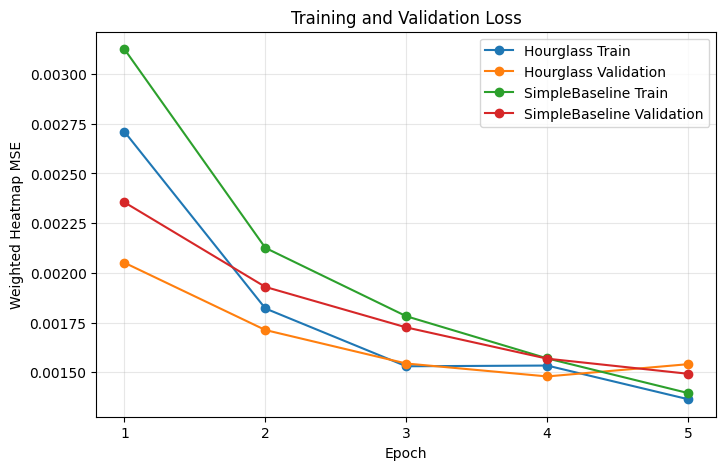

In [76]:
# ============================================================
# Step 13-1. Training / Validation Loss Curves
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))

plt.plot(
    hourglass_history_df["epoch"],
    hourglass_history_df["train_final_loss"],
    marker="o",
    label="Hourglass Train",
)

plt.plot(
    hourglass_history_df["epoch"],
    hourglass_history_df["val_final_loss"],
    marker="o",
    label="Hourglass Validation",
)

plt.plot(
    simple_history_df["epoch"],
    simple_history_df["train_final_loss"],
    marker="o",
    label="SimpleBaseline Train",
)

plt.plot(
    simple_history_df["epoch"],
    simple_history_df["val_final_loss"],
    marker="o",
    label="SimpleBaseline Validation",
)

plt.xlabel("Epoch")
plt.ylabel("Weighted Heatmap MSE")
plt.title("Training and Validation Loss")
plt.xticks(
    hourglass_history_df["epoch"]
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [77]:
# ============================================================
# Step 13-2. 최종 비교 분석
# ============================================================

comparison_df = pd.DataFrame([
    {
        "Model": "Stacked Hourglass",
        "Parameters (M)": 16_251_392 / 1e6,
        "Best Epoch": 4,
        "Best Val Loss": 0.001479,
        "Train min / Epoch": 7.203,
        "Peak GPU Memory (GB)": 6.582,
        "Samples / sec": 52.887,
    },
    {
        "Model": "SimpleBaseline",
        "Parameters (M)": 33_999_440 / 1e6,
        "Best Epoch": 5,
        "Best Val Loss": 0.001492,
        "Train min / Epoch": 2.597,
        "Peak GPU Memory (GB)": 5.117,
        "Samples / sec": 145.900,
    },
])

display(
    comparison_df.round({
        "Parameters (M)": 2,
        "Best Val Loss": 6,
        "Train min / Epoch": 2,
        "Peak GPU Memory (GB)": 2,
        "Samples / sec": 2,
    })
)

,Model,Parameters (M),Best Epoch,Best Val Loss,Train min / Epoch,Peak GPU Memory (GB),Samples / sec
0,Stacked Hourglass,16.25,4,0.001479,7.2,6.58,52.89
1,SimpleBaseline,34.00,5,0.001492,2.6,5.12,145.90


In [78]:
# ============================================================
# Step 14-1. 베스트 체크포인트 불러오기
# ============================================================

import gc
import torch


gc.collect()
torch.cuda.empty_cache()


hourglass_best_path = (
    MODEL_DIR
    / "stacked_hourglass"
    / "best.pt"
)

simple_best_path = (
    MODEL_DIR
    / "simple_baseline"
    / "best.pt"
)


hourglass_checkpoint = torch.load(
    hourglass_best_path,
    map_location=device,
    weights_only=False,
)

simple_checkpoint = torch.load(
    simple_best_path,
    map_location=device,
    weights_only=False,
)


print(
    "Hourglass best epoch:",
    hourglass_checkpoint["epoch"]
)

print(
    "SimpleBaseline best epoch:",
    simple_checkpoint["epoch"]
)

Hourglass best epoch: 4
SimpleBaseline best epoch: 5


In [79]:
# ============================================================
# Step 14-2. best model 복원
# ============================================================

hourglass_best_model = (
    StackedHourglassNetwork(
        num_stack=4,
        num_residual=1,
        num_heatmap=NUM_JOINTS,
    )
    .to(device)
)


hourglass_best_model.load_state_dict(
    hourglass_checkpoint[
        "model_state_dict"
    ]
)


simple_best_model = (
    SimpleBaseline(
        num_joints=NUM_JOINTS,
        weights=None,
    )
    .to(device)
)


simple_best_model.load_state_dict(
    simple_checkpoint[
        "model_state_dict"
    ]
)


hourglass_best_model.eval()
simple_best_model.eval()


print("Best models restored.")

Best models restored.


In [80]:
# ============================================================
# Step 14-3. Heatmap 가장 값이 높은 픽셀값 보기
# ============================================================

def heatmaps_to_joints(
    heatmaps,
    input_width=256,
    input_height=256,
):

    # [J, H, W]
    num_joints, heatmap_h, heatmap_w = (
        heatmaps.shape
    )

    flattened = heatmaps.reshape(
        num_joints,
        -1,
    )

    peak_indices = flattened.argmax(
        dim=1
    )


    y = (
        peak_indices
        // heatmap_w
    )

    x = (
        peak_indices
        % heatmap_w
    )


    # Heatmap 좌표 → 256×256 input 좌표
    x_input = (
        x.float()
        * input_width
        / heatmap_w
    )

    y_input = (
        y.float()
        * input_height
        / heatmap_h
    )


    joints = torch.stack(
        [
            x_input,
            y_input,
        ],
        dim=1,
    )


    return joints

In [81]:
# ============================================================
# Step 14-4. 같은 검증 샘플에서 두 모델의 예측 보기
# ============================================================

_, visualization_val_loader = (
    make_dataloaders(SEED)
)


val_batch = next(
    iter(visualization_val_loader)
)


val_images = val_batch[
    "image"
].to(
    device,
    non_blocking=True,
)


with torch.inference_mode():

    hg_outputs = (
        hourglass_best_model(
            val_images
        )
    )

    hg_heatmaps = (
        hg_outputs[-1]
    )


    sb_heatmaps = (
        simple_best_model(
            val_images
        )
    )


sample_id = 0


gt_joints = val_batch[
    "joints_input"
][sample_id]


target_weight = val_batch[
    "target_weight"
][sample_id]


hg_joints = heatmaps_to_joints(
    hg_heatmaps[
        sample_id
    ].cpu()
)


sb_joints = heatmaps_to_joints(
    sb_heatmaps[
        sample_id
    ].cpu()
)


print(
    "GT:",
    gt_joints.shape
)

print(
    "Hourglass:",
    hg_joints.shape
)

print(
    "SimpleBaseline:",
    sb_joints.shape
)

GT: torch.Size([16, 2])
Hourglass: torch.Size([16, 2])
SimpleBaseline: torch.Size([16, 2])


In [82]:
# ============================================================
# Step 14-5. 이미지 복원
# ============================================================

def denormalize_image(
    tensor,
):

    image = (
        tensor.cpu()
        * IMAGENET_STD
        + IMAGENET_MEAN
    )

    image = (
        image
        .clamp(0, 1)
        .permute(1, 2, 0)
        .numpy()
    )

    return image

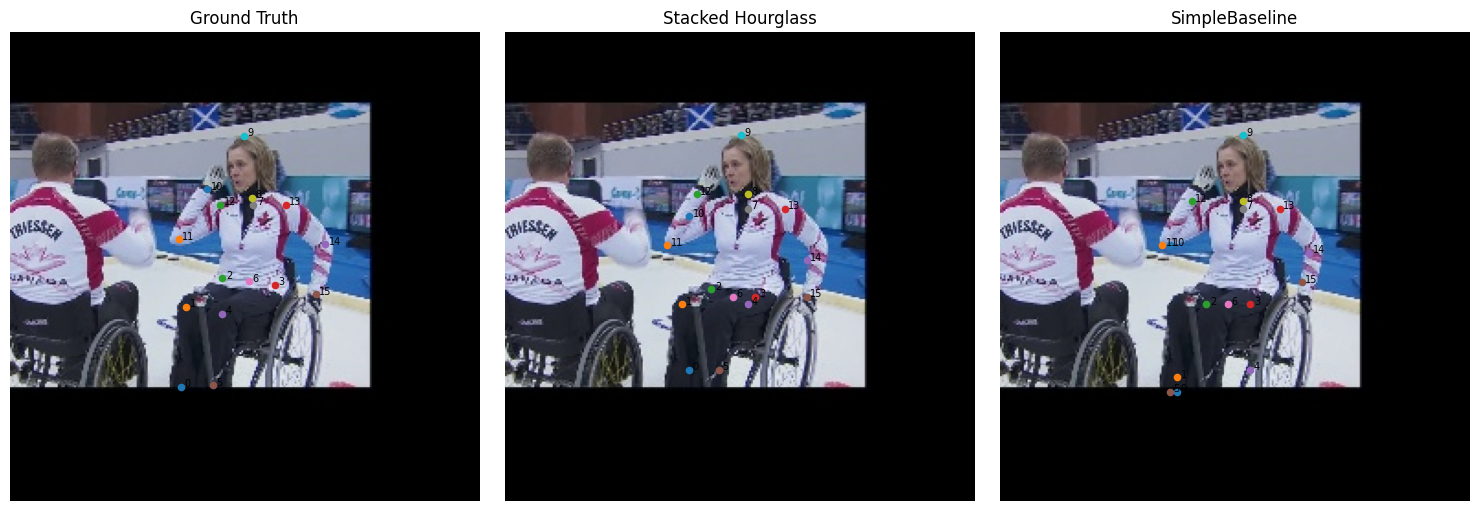

In [83]:
# ============================================================
# Step 14-6. GT / Hourglass / SimpleBaselin 비교!
# ============================================================

image = denormalize_image(
    val_batch["image"][sample_id]
)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
)


titles = [
    "Ground Truth",
    "Stacked Hourglass",
    "SimpleBaseline",
]


joint_sets = [
    gt_joints,
    hg_joints,
    sb_joints,
]


for ax, title, joints in zip(
    axes,
    titles,
    joint_sets,
):

    ax.imshow(image)


    for joint_id, (x, y) in enumerate(
        joints
    ):

        # GT visibility를 공통 mask로 사용
        if (
            target_weight[
                joint_id
            ] <= 0
        ):
            continue


        ax.scatter(
            float(x),
            float(y),
            s=20,
        )


        ax.text(
            float(x) + 2,
            float(y),
            str(joint_id),
            fontsize=7,
        )


    ax.set_title(title)
    ax.axis("off")


plt.tight_layout()
plt.show()

### 중간 결론

5 epoch의 동일 조건 학습 결과,
Stacked Hourglass는 Epoch 4에서
best validation loss **0.001479**를 기록

SimpleBaseline은 Epoch 5에서
best validation loss **0.001492**를 기록

두 모델의 validation heatmap MSE 차이는 매우 작았으며,
현재의 단일 seed 및 5 epoch 실험만으로
두 모델의 pose estimation 성능 차이가 유의미하진 않은 듯 함.

계산 효율에서는 뚜렷한 차이가 나타남

- Stacked Hourglass: 약 7.20 min/epoch
- SimpleBaseline: 약 2.60 min/epoch

SimpleBaseline은 Stacked Hourglass보다 parameter 수가 많았지만,
실제 학습은 훨씬 빠르고 GPU memory 사용량도 더 낮았다.

이는 모델의 계산 비용이 parameter 수뿐 아니라
feature-map resolution, intermediate activation,
multi-scale processing 구조 등에 크게 영향을 받는다는 것을 보여준다.

Stacked Hourglass는 반복적인 multi-scale feature fusion과
intermediate supervision을 수행하는 반면,
SimpleBaseline은 ResNet backbone에서 spatial resolution을 크게 줄인 뒤
3개의 transposed convolution으로 heatmap resolution을 복원한다.

따라서 이번 실험은 두 구조가 유사한 validation loss에 도달하면서도
계산 효율 측면에서는 상당히 다른 특성을 보인다는 걸 확인했다.

## Step 15. Joint Localization Error

Heatmap MSE만으로는 실제 관절 위치 오차를 직접 확인하기 어렵다.

따라서 동일한 validation dataset에 대해
각 heatmap의 maximum 위치를 joint prediction으로 변환하고,
Ground Truth joint 좌표와의 Euclidean distance를 계산한다.

본 지표는 256×256 affine-cropped input 좌표계에서 계산한
**Mean Joint Pixel Error**이며,
공식 MPII PCKh metric을 대체하는 지표는 아니다.

낮을수록 Ground Truth 관절 위치에 가까운 예측을 의미한다.

In [84]:
# ============================================================
# Step 15-1. 검증 전체에서 두 모델을 동시에 평가해보기.
# ============================================================

import numpy as np
import torch
from tqdm.auto import tqdm


JOINT_NAMES = [
    "right_ankle",
    "right_knee",
    "right_hip",
    "left_hip",
    "left_knee",
    "left_ankle",
    "pelvis",
    "thorax",
    "upper_neck",
    "head_top",
    "right_wrist",
    "right_elbow",
    "right_shoulder",
    "left_shoulder",
    "left_elbow",
    "left_wrist",
]


def compute_joint_distances(
    predicted_joints,
    gt_joints,
    target_weight,
):
    """
    predicted_joints : [B, J, 2]
    gt_joints        : [B, J, 2]
    target_weight    : [B, J]

    return:
        distances    : [B, J]
        valid_mask   : [B, J]
    """

    distances = torch.linalg.vector_norm(
        predicted_joints - gt_joints,
        ord=2,
        dim=-1,
    )

    valid_mask = (
        target_weight > 0
    )

    return distances, valid_mask

In [85]:
# ============================================================
# 배치용 peak 변환 함수
# ============================================================

def batch_heatmaps_to_joints(
    heatmaps,
    input_width=256,
    input_height=256,
):
    """
    heatmaps:
        [B, J, H, W]

    return:
        joints:
        [B, J, 2]
    """

    batch_size, num_joints, h, w = (
        heatmaps.shape
    )

    flattened = heatmaps.reshape(
        batch_size,
        num_joints,
        -1,
    )

    peak_indices = flattened.argmax(
        dim=-1
    )

    y = peak_indices // w
    x = peak_indices % w

    x_input = (
        x.float()
        * input_width
        / w
    )

    y_input = (
        y.float()
        * input_height
        / h
    )

    joints = torch.stack(
        [
            x_input,
            y_input,
        ],
        dim=-1,
    )

    return joints

In [86]:
# ============================================================
# Step 15-2. 전체 검증 루프
# ============================================================

_, metric_val_loader = (
    make_dataloaders(SEED)
)


hourglass_best_model.eval()
simple_best_model.eval()


hg_error_sum = torch.zeros(
    NUM_JOINTS,
    dtype=torch.float64,
)

sb_error_sum = torch.zeros(
    NUM_JOINTS,
    dtype=torch.float64,
)

joint_counts = torch.zeros(
    NUM_JOINTS,
    dtype=torch.float64,
)


all_hg_errors = []
all_sb_errors = []


with torch.inference_mode():

    for batch in tqdm(
        metric_val_loader,
        desc="Localization evaluation",
    ):

        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        gt_joints = batch[
            "joints_input"
        ].to(
            device,
            non_blocking=True,
        )

        target_weight = batch[
            "target_weight"
        ].to(
            device,
            non_blocking=True,
        )


        # ------------------------------------------
        # Hourglass
        # ------------------------------------------

        hg_outputs = (
            hourglass_best_model(
                images
            )
        )

        hg_heatmaps = (
            hg_outputs[-1]
        )

        hg_pred = (
            batch_heatmaps_to_joints(
                hg_heatmaps,
                INPUT_WIDTH,
                INPUT_HEIGHT,
            )
        )


        # ------------------------------------------
        # SimpleBaseline
        # ------------------------------------------

        sb_heatmaps = (
            simple_best_model(
                images
            )
        )

        sb_pred = (
            batch_heatmaps_to_joints(
                sb_heatmaps,
                INPUT_WIDTH,
                INPUT_HEIGHT,
            )
        )


        # ------------------------------------------
        # Distance
        # ------------------------------------------

        hg_dist, valid_mask = (
            compute_joint_distances(
                hg_pred,
                gt_joints,
                target_weight,
            )
        )

        sb_dist, _ = (
            compute_joint_distances(
                sb_pred,
                gt_joints,
                target_weight,
            )
        )


        mask_float = (
            valid_mask.float()
        )


        hg_error_sum += (
            (hg_dist * mask_float)
            .sum(dim=0)
            .cpu()
            .double()
        )

        sb_error_sum += (
            (sb_dist * mask_float)
            .sum(dim=0)
            .cpu()
            .double()
        )

        joint_counts += (
            mask_float
            .sum(dim=0)
            .cpu()
            .double()
        )


        all_hg_errors.extend(
            hg_dist[
                valid_mask
            ]
            .cpu()
            .tolist()
        )

        all_sb_errors.extend(
            sb_dist[
                valid_mask
            ]
            .cpu()
            .tolist()
        )

Localization evaluation: 0it [00:00, ?it/s]

In [87]:
# ============================================================
# Step 15-3. 전체 평균과 중앙값
# ============================================================

hg_mean_error = np.mean(
    all_hg_errors
)

sb_mean_error = np.mean(
    all_sb_errors
)


hg_median_error = np.median(
    all_hg_errors
)

sb_median_error = np.median(
    all_sb_errors
)


print(
    "Stacked Hourglass"
)

print(
    "  Mean pixel error  :",
    f"{hg_mean_error:.3f}"
)

print(
    "  Median pixel error:",
    f"{hg_median_error:.3f}"
)


print(
    "\nSimpleBaseline"
)

print(
    "  Mean pixel error  :",
    f"{sb_mean_error:.3f}"
)

print(
    "  Median pixel error:",
    f"{sb_median_error:.3f}"
)

Stacked Hourglass
  Mean pixel error  : 13.105
  Median pixel error: 6.048

SimpleBaseline
  Mean pixel error  : 14.064
  Median pixel error: 7.198


In [88]:
# ============================================================
# Step 15-4. 관절별 오차 확인하기
# ============================================================

hg_joint_error = (
    hg_error_sum
    / joint_counts.clamp_min(1)
)

sb_joint_error = (
    sb_error_sum
    / joint_counts.clamp_min(1)
)


joint_error_df = pd.DataFrame({
    "Joint": JOINT_NAMES,

    "Stacked Hourglass":
        hg_joint_error.numpy(),

    "SimpleBaseline":
        sb_joint_error.numpy(),

    "Visible Samples":
        joint_counts.numpy().astype(int),
})


joint_error_df[
    "Difference (SB - HG)"
] = (
    joint_error_df[
        "SimpleBaseline"
    ]
    -
    joint_error_df[
        "Stacked Hourglass"
    ]
)


display(
    joint_error_df.round(3)
)

,Joint,Stacked Hourglass,SimpleBaseline,Visible Samples,Difference (SB - HG)
0,right_ankle,21.619,24.362,2067,2.743
1,right_knee,17.884,18.883,2483,0.999
2,right_hip,11.945,12.020,2889,0.075
3,left_hip,12.133,12.128,2887,-0.005
4,left_knee,17.561,18.166,2477,0.604
5,left_ankle,21.426,23.938,2075,2.512
6,pelvis,9.943,10.232,2877,0.289
7,thorax,5.565,6.191,2931,0.626
8,upper_neck,4.976,5.591,2930,0.616
9,head_top,7.054,8.050,2852,0.997


In [89]:
# ============================================================
# Step 15-5.10픽셀 이내 조인트 비율~ Threshold 정확도 보기
# ============================================================

PIXEL_THRESHOLDS = [
    5,
    10,
    20,
]


threshold_rows = []


for threshold in PIXEL_THRESHOLDS:

    hg_accuracy = (
        np.mean(
            np.asarray(
                all_hg_errors
            ) <= threshold
        )
    )

    sb_accuracy = (
        np.mean(
            np.asarray(
                all_sb_errors
            ) <= threshold
        )
    )


    threshold_rows.append({
        "Threshold (px)":
            threshold,

        "Stacked Hourglass":
            hg_accuracy,

        "SimpleBaseline":
            sb_accuracy,
    })


threshold_df = pd.DataFrame(
    threshold_rows
)


display(
    threshold_df.style.format({
        "Stacked Hourglass":
            "{:.2%}",

        "SimpleBaseline":
            "{:.2%}",
    })
)

,Threshold (px),Stacked Hourglass,SimpleBaseline
0,5,42.37%,35.41%
1,10,66.94%,62.28%
2,20,81.65%,80.06%


| 기준      | Stacked Hourglass | SimpleBaseline |      차이 |
| ------- | ----------------: | -------------: | ------: |
| 5px 이내  |        **42.37%** |         35.41% | +6.96%p |
| 10px 이내 |        **66.94%** |         62.28% | +4.66%p |
| 20px 이내 |        **81.65%** |         80.06% | +1.59%p |


### 왜 손목·발목에서 Hourglass가 더 유리했을까



```
몸통
→ 크고 안정적
→ 주변 context가 많음

손목 / 발목
→ 작음
→ 자세 변화가 큼
→ 가림 가능성이 큼
→ 이미지 경계에 걸리기도 함
```

SimpleBaseline의 경우


```
고해상도 입력
↓
ResNet
↓
8×8까지 강하게 압축
↓
Deconv
↓
64×64 복원
```

Hourglass는


```
high-resolution feature
        ↘
         low-resolution context
        ↗
high-resolution feature

× 반복
```


그래서 전신의 큰 구조적 context와 세밀한 spatial localization을 반복적으로 결합하는 Hourglass 구조가 특히 말단 관절의 정밀한 위치 추정에 도움이 되었을 가능성...



## 최종 비교

동일한 MPII dataset, preprocessing, optimizer, learning rate,
batch size, epoch 수 및 loss function을 사용하여
Stacked Hourglass와 SimpleBaseline을 비교했다.

### 1. Heatmap loss

5 epoch 학습 결과 best validation heatmap MSE는:

- Stacked Hourglass: **0.001479** (Epoch 4)
- SimpleBaseline: **0.001492** (Epoch 5)

로 매우 유사한 결과나 나왔다.

따라서 heatmap MSE만으로는 두 모델 사이에
큰 성능 차이가 있다고 보기 어려웠다.

### 2. Joint localization

Heatmap maximum을 joint coordinate로 변환하여
256×256 input 좌표계에서 Ground Truth와의 pixel distance를 비교하였다.

5 pixel 이내 정확도:

- Stacked Hourglass: **42.37%**
- SimpleBaseline: **35.41%**

10 pixel 이내 정확도:

- Stacked Hourglass: **66.94%**
- SimpleBaseline: **62.28%**

20 pixel 이내 정확도:

- Stacked Hourglass: **81.65%**
- SimpleBaseline: **80.06%**

허용 오차가 작을수록 Stacked Hourglass의 우위가 더 크게 나타났다!!

특히 ankle과 wrist와 같은 말단 관절에서
Stacked Hourglass의 평균 pixel error가 더 낮게 나타났다.

이는 반복적인 multi-scale processing과 feature fusion을 수행하는
Hourglass 구조가 세밀한 spatial localization에 도움이 되었을 가능성을 보여준다.

### 3. Computational efficiency

반면 계산 효율에서는 SimpleBaseline이 크게 우세하였다.

- Stacked Hourglass: 약 **7.20 min/epoch**
- SimpleBaseline: 약 **2.60 min/epoch**

Peak GPU memory:

- Stacked Hourglass: **6.58 GB**
- SimpleBaseline: **5.12 GB**

SimpleBaseline은 약 34M parameter로
Stacked Hourglass의 약 16M parameter보다 parameter 수가 많았지만,
실제 학습 속도는 훨씬 빠르고 GPU memory 사용량도 더 낮았다.

이는 모델의 computational cost가 parameter 수뿐 아니라
feature-map resolution, intermediate activation,
multi-scale computation 구조에 크게 영향을 받는다는 것을 보여준다.

### 결론

본 실험에서 두 모델은 heatmap MSE 기준으로는 유사한 성능을 보였지만,
joint localization 기준에서는 Stacked Hourglass가 더 정밀한 예측을 보였다.

특히 손목과 발목 등의 어려운 말단 관절에서
Stacked Hourglass의 advantage가 상대적으로 크게 나타났다.

반면 SimpleBaseline은 매우 단순한 upsampling 구조만으로
Stacked Hourglass와 유사한 heatmap loss에 도달하면서
약 2.8배 높은 throughput과 더 낮은 GPU memory 사용량을 보였다.

따라서 이번 실험에서는:

- **정밀한 spatial localization 측면에서는 Stacked Hourglass**
- **계산 효율과 구현 단순성 측면에서는 SimpleBaseline**

이 각각 장점을 갖는 것으로 해석할 수 있다.

단, 본 실험은 단일 seed와 5 epoch 학습에 기반한 비교이며,
pixel-distance metric은 공식 MPII PCKh가 아닌
프로젝트 내부 상대 비교 지표이므로
일반적인 모델 성능 순위로 확대 해석하지 않는다.

# 회고. 오늘은 조금 진지한 회고.

U-Net 이후 계속해서 해상도를 낮추고 높이고, skip connection으로 다시 합치고, 여러 scale의 feature를 반복적으로 교환하는 구조를 따라가다 보니 어느 순간에는 각 모델의 레이어를 이해하는 일 자체에 지쳐 있었다.

Pose Estimation에서도 결국 사람의 몸을 하나의 값으로 예측하는 것이 아니라, 관절마다 공간적인 heatmap을 만들고 위치 정보를 보존하거나 복원하기 위해 또 다른 방식으로 feature를 쌓고 결합한다는 사실을 보면서, 지금의 딥러닝 구조들이 수많은 연구자들이 같은 문제를 조금씩 다른 관점에서 풀어 온 방대한 시행착오의 결과라는 것을 다시 느꼈다.


동시에 이런 구조를 하나하나 배우다 보면 오히려 더 큰 질문이 남는다.

`이미 대규모 데이터와 막대한 컴퓨팅 자원으로 사전학습된 frontier model과 강력한 backbone이 존재하는 상황에서, 내가 CNN의 레이어 몇 개를 새롭게 조합한다고 해서 그것들을 넘어서는 모델을 만들 수 있을까` 하는 의문이다.

그래서 공개되는 새로운 모델과 open weight 소식을 놓칠까 봐 계속 관련 뉴스나 커뮤니티의 정보를 수집하게 되고, 정작 그것들을 직접 검증하고 응용하기에는 아직 내 엔지니어링 역량이 부족하다는 생각 때문에 다시 원점으로 돌아온 듯한 두려움도 있다.

그런데 오늘 실험은 내가 반드시 새로운 CNN 구조를 발명해야만 이 공부가 의미 있는 것은 아니라는 점을 조금 다르게 보여주었다.

같은 MPII 데이터, 같은 전처리, 같은 heatmap, 같은 optimizer와 learning rate, 같은 epoch 조건에서 모델 구조만 바꾸어 보니, Stacked Hourglass는 약 1,625만 개의 parameter를 가지고도 반복적인 multi-scale processing 때문에 더 많은 GPU memory와 시간을 사용했고, SimpleBaseline은 약 3,400만 개의 parameter를 가지고 있음에도 훨씬 빠르고 가볍게 학습되었다.
반대로 최종 heatmap MSE는 두 모델이 거의 비슷했지만, 실제 관절 위치를 비교했을 때는 Hourglass가 특히 손목과 발목 같은 말단 관절에서 더 정밀한 localization을 보여주었다. 즉 parameter가 많다고 반드시 느린 것도 아니고, loss가 거의 같다고 실제 공간적 예측까지 같은 것도 아니었다.

이 결과를 보면서 내가 앞으로 모델을 바라볼 때 중요한 질문은 “어떤 모델이 더 최신인가”, “어떤 구조가 더 복잡한가”가 아니라 “이 구조는 무엇을 얻기 위해 어떤 비용을 지불하고 있는가”에 가까워져야 한다고 느꼈다.

결국 모델을 이해한다는 것은 모든 레이어를 외우는 것이 아니라, 구조적 선택과 그 선택이 만들어내는 성능·속도·메모리·일반화 사이의 trade-off를 읽을 수 있게 되는 일에 더 가깝다는 생각이 들었다.

그래서 오늘의 실습은 내가 frontier model을 직접 뛰어넘기 위한 첫걸음이라기보다, 앞으로 공개된 모델과 open weight를 **무작정 따라 쓰는 사람이 아니라, 왜 이 모델을 선택하는지 판단할 수 있는 사람이 되기 위한 연습**이었다고 정리하고 싶다.

새로운 AI 소식을 계속 따라가야 한다는 불안 자체가 사라진 것은 아니지만, 모든 모델을 직접 구현하고 모든 논문을 따라잡는 것이 목표일 필요는 없다는 것도 조금씩 알게 된다. 대신 데이터가 어떻게 만들어졌는지, 어떤 backbone에 의존하는지, 어떤 정보가 spatial resolution을 따라 사라지고 복원되는지, 동일한 조건에서 무엇이 실제로 달라지는지를 실험으로 확인할 수 있다면, 공개된 거대한 모델을 사용할 때에도 그 결과를 훨씬 더 비판적으로 이해하고 활용할 수 있을 것이다.
